In [38]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('plots', exist_ok=True)


print("Učitavanje dataseta...")
df = pd.read_parquet('datasets/block1_train.parquet', engine="fastparquet")
print(f"Shape: {df.shape}")

insurer_cols = [f'Insurer_{c}_price' for c in 'ABCDEFGHIJK']
deduct_cols  = [f'Insurer_{c}_deductible' for c in 'ABCDEFGHIJK']
insurers     = [c.replace('_price', '') for c in insurer_cols]

REF_DATE = pd.Timestamp('2025-12-27')

# Konverzije
for col in insurer_cols + deduct_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['contractor_birthdate'] = pd.to_datetime(df['contractor_birthdate'], errors='coerce')
df['second_driver_birthdate'] = pd.to_datetime(df['second_driver_birthdate'], errors='coerce')
df['vehicle_first_registration_date'] = pd.to_datetime(df['vehicle_first_registration_date'], errors='coerce')

df['driver_age']       = (REF_DATE - df['contractor_birthdate']).dt.days / 365.25
df['vehicle_age_calc'] = (REF_DATE - df['vehicle_first_registration_date']).dt.days / 365.25
df['claim_free_years'] = pd.to_numeric(df['claim_free_years'], errors='coerce')
df['second_driver_cfr'] = pd.to_numeric(df['second_driver_claim_free_years'], errors='coerce')
df['vehicle_value_new'] = pd.to_numeric(df['vehicle_value_new'], errors='coerce')
df['vehicle_power']     = pd.to_numeric(df['vehicle_power'], errors='coerce')
df['municipality_crimes_per_1000'] = pd.to_numeric(df['municipality_crimes_per_1000'], errors='coerce')

df.loc[df['driver_age'] < 17, 'driver_age'] = np.nan

df['is_bad_driver']  = (df['claim_free_years'] < 0).astype(int)
df['num_quotes']     = df[insurer_cols].notnull().sum(axis=1)
df['market_median']  = df[insurer_cols].median(axis=1)
df['market_min']     = df[insurer_cols].min(axis=1)
df['has_second_driver'] = df['second_driver_birthdate'].notnull().astype(int)

# Grupe
df['age_group'] = pd.cut(
    df['driver_age'],
    bins=[0, 25, 35, 45, 55, 65, 120],
    labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+']
)
df['vehicle_value_group'] = pd.cut(
    df['vehicle_value_new'],
    bins=[0, 10000, 20000, 35000, 50000, 75000, 999999],
    labels=['<10k', '10-20k', '20-35k', '35-50k', '50-75k', '75k+']
)
df['cfr_group'] = pd.cut(
    df['claim_free_years'],
    bins=[-50, -1, 0, 3, 7, 15, 100],
    labels=['Veoma loš (<-1)', 'Loš (-1 do 0)', 'Novi (0-3)',
            'Dobar (3-7)', 'Odličan (7-15)', 'Veteran (15+)']
)

sns.set_theme(style='whitegrid', font_scale=1.1)
print("✅ Setup gotov\n")

Učitavanje dataseta...
Shape: (541292, 155)
Shape: (541292, 155)
✅ Setup gotov

✅ Setup gotov



=== ANALIZA A: DEDUCTIBLE STRATEGY ===
Prosečni deductible po insureru:
  Insurer_G: 121€  (deductible/premija: 143%)
  Insurer_J: 120€  (deductible/premija: 114%)
  Insurer_A: 116€  (deductible/premija: 120%)
  Insurer_B: 109€  (deductible/premija: 109%)
  Insurer_C: 104€  (deductible/premija: 117%)
  Insurer_E: 86€  (deductible/premija: 74%)
  Insurer_K: 11€  (deductible/premija: 9%)
  Insurer_H: 6€  (deductible/premija: 6%)
  Insurer_F: 4€  (deductible/premija: 4%)
  Insurer_I: 3€  (deductible/premija: 4%)
  Insurer_D: 1€  (deductible/premija: 1%)

True Cost ranking (cena + 10%×deductible):
  Insurer_K: 125€  (premija: 124€, deductible: 11€)
  Insurer_E: 124€  (premija: 116€, deductible: 86€)
  Insurer_H: 117€  (premija: 116€, deductible: 6€)
  Insurer_J: 117€  (premija: 105€, deductible: 120€)
  Insurer_B: 111€  (premija: 100€, deductible: 109€)
  Insurer_A: 109€  (premija: 97€, deductible: 116€)
  Insurer_C: 100€  (premija: 89€, deductible: 104€)
  Insurer_D: 99€  (premija: 98€, d

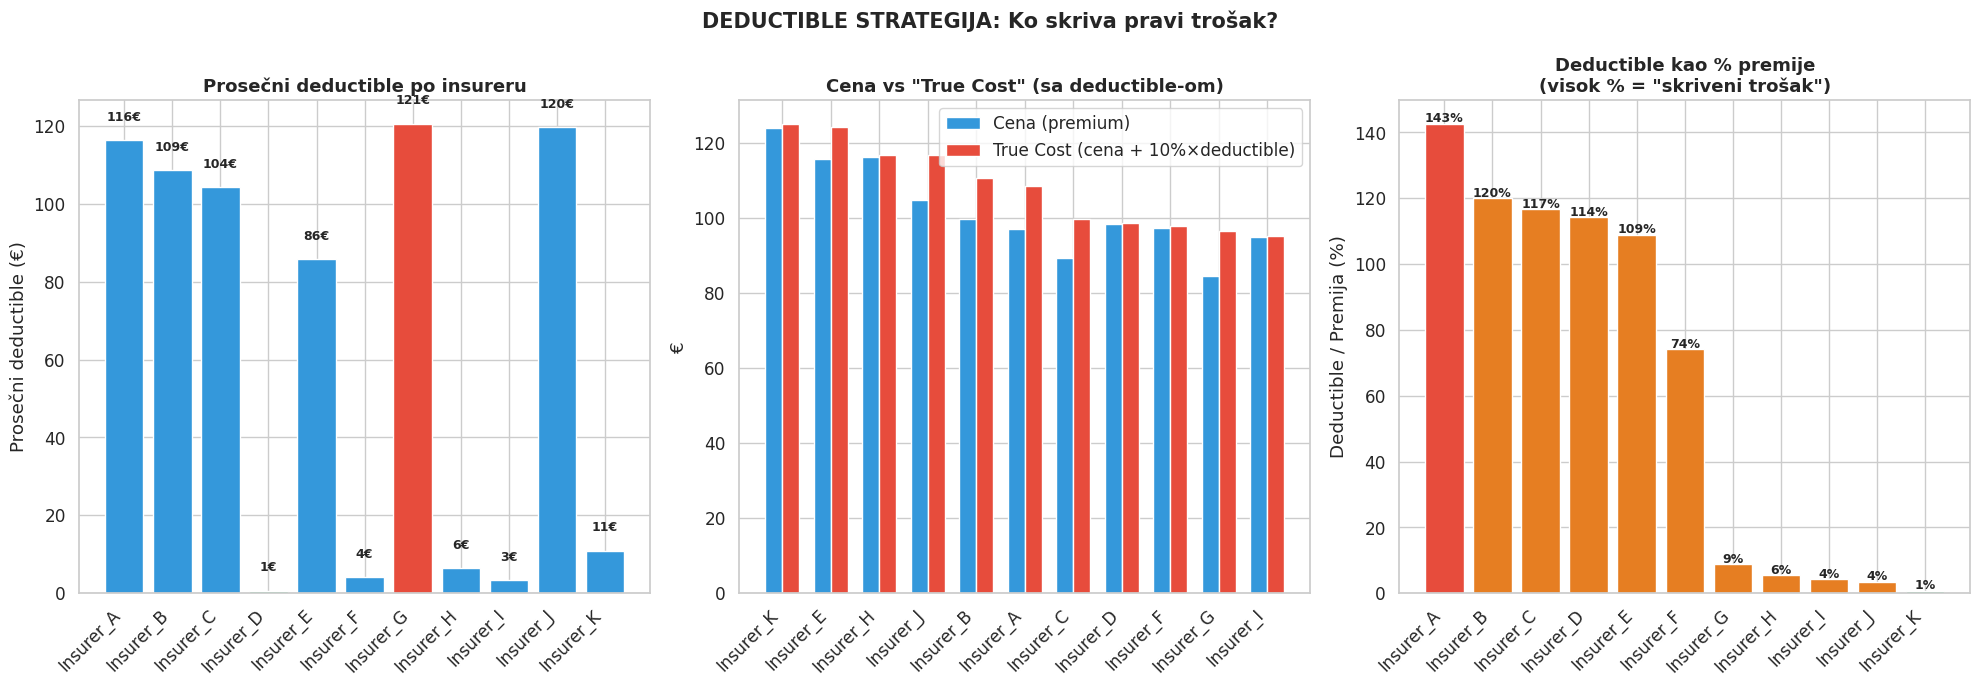

In [60]:

# ============================================================
# ANALIZA A — DEDUCTIBLE STRATEGY: "Pravi trošak" osiguranja
# ============================================================
print("=== ANALIZA A: DEDUCTIBLE STRATEGY ===")

# Prosečni deductible po insureru
mean_deduct = df[deduct_cols].mean()
mean_deduct.index = [c.replace('_deductible','') for c in mean_deduct.index]

mean_price = df[insurer_cols].mean()
mean_price.index = [c.replace('_price','') for c in mean_price.index]

# "True cost" = price + 10% * deductible (pretpostavljamo 10% šansu za claim godišnje)
claim_prob = 0.10
true_cost = mean_price + claim_prob * mean_deduct
true_cost = true_cost.sort_values(ascending=False)

# Deductible kao % cene
deduct_pct = (mean_deduct / mean_price * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Graf 1: Prosečni deductible
colors_d = ['#e74c3c' if v == mean_deduct.max() else '#2ecc71' if v == mean_deduct.min() else '#3498db'
            for v in mean_deduct.values]
axes[0].bar(mean_deduct.index, mean_deduct.values, color=colors_d, edgecolor='white')
axes[0].set_xticklabels(
    axes[0].get_xticklabels(), 
    rotation=45, 
    ha='right'
)
axes[0].set_title('Prosečni deductible po insureru', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Prosečni deductible (€)')
for i, v in enumerate(mean_deduct.values):
    axes[0].text(i, v + 5, f'{v:.0f}€', ha='center', fontsize=9, fontweight='bold')

# Graf 2: Cena vs True Cost
x = np.arange(len(true_cost))
width = 0.35
axes[1].bar(x - width/2, mean_price[true_cost.index].values, width, label='Cena (premium)', color='#3498db', edgecolor='white')
axes[1].bar(x + width/2, true_cost.values, width, label='True Cost (cena + 10%×deductible)', color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x, rotation = 45)
axes[1].set_xticklabels(
    axes[0].get_xticklabels(), 
    rotation=45, 
    ha='right'
)
axes[1].set_xticklabels(true_cost.index)
axes[1].set_title('Cena vs "True Cost" (sa deductible-om)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('€')
axes[1].legend()

# Graf 3: Deductible kao % cene — "koliko skrivaju"
colors_pct = ['#e74c3c' if v == deduct_pct.max() else '#2ecc71' if v == deduct_pct.min() else '#e67e22'
              for v in deduct_pct.values]
axes[2].bar(deduct_pct.index, deduct_pct.values, color=colors_pct, edgecolor='white')
axes[2].set_title('Deductible kao % premije\n(visok % = "skriveni trošak")', fontsize=13, fontweight='bold')
axes[2].set_xticklabels(
    axes[0].get_xticklabels(), 
    rotation=45, 
    ha='right'
)
axes[2].set_ylabel('Deductible / Premija (%)')
for i, v in enumerate(deduct_pct.values):
    axes[2].text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('DEDUCTIBLE STRATEGIJA: Ko skriva pravi trošak?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/A_deductible_strategy.png', dpi=150, bbox_inches='tight')


print("Prosečni deductible po insureru:")
for ins, val in mean_deduct.sort_values(ascending=False).items():
    print(f"  {ins}: {val:.0f}€  (deductible/premija: {deduct_pct[ins]:.0f}%)")

print("\nTrue Cost ranking (cena + 10%×deductible):")
for ins, val in true_cost.items():
    print(f"  {ins}: {val:.0f}€  (premija: {mean_price[ins]:.0f}€, deductible: {mean_deduct[ins]:.0f}€)")

# Deductible po coverage tipu
print("\nDeductible po coverage tipu:")
for cov in ['mtpl', 'limited_casco', 'casco']:
    sub = df[df['coverage'] == cov]
    d = sub[deduct_cols].mean()
    d.index = [c.replace('_deductible','') for c in d.index]
    print(f"\n  {cov.upper()}:")
    for ins, val in d.sort_values(ascending=False).items():
        print(f"    {ins}: {val:.0f}€")

print("✅ Analiza A gotova\n")

=== ANALIZA B: WIN RATE ANALIZA ===
Ukupni Win Rate:
  Insurer_A: 50.2% profila
  Insurer_F: 13.4% profila
  Insurer_G: 10.4% profila
  Insurer_C: 6.8% profila
  Insurer_I: 6.4% profila
  Insurer_D: 4.6% profila
  Insurer_E: 2.5% profila
  Insurer_B: 2.4% profila
  Insurer_J: 1.7% profila
  Insurer_H: 1.0% profila
  Insurer_K: 0.7% profila

Win Rate po coverage tipu (%):
winner         Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
coverage                                                                                                                              
casco               65.1        1.9        4.2        5.6        2.0        8.7        3.5        0.1        5.8        2.7        0.5
limited_casco       45.7        3.6        8.5        3.4        2.7       19.6        4.8        0.0        8.8        1.9        1.0
mtpl                40.5        0.9        7.0        5.4        2.6        8.3       

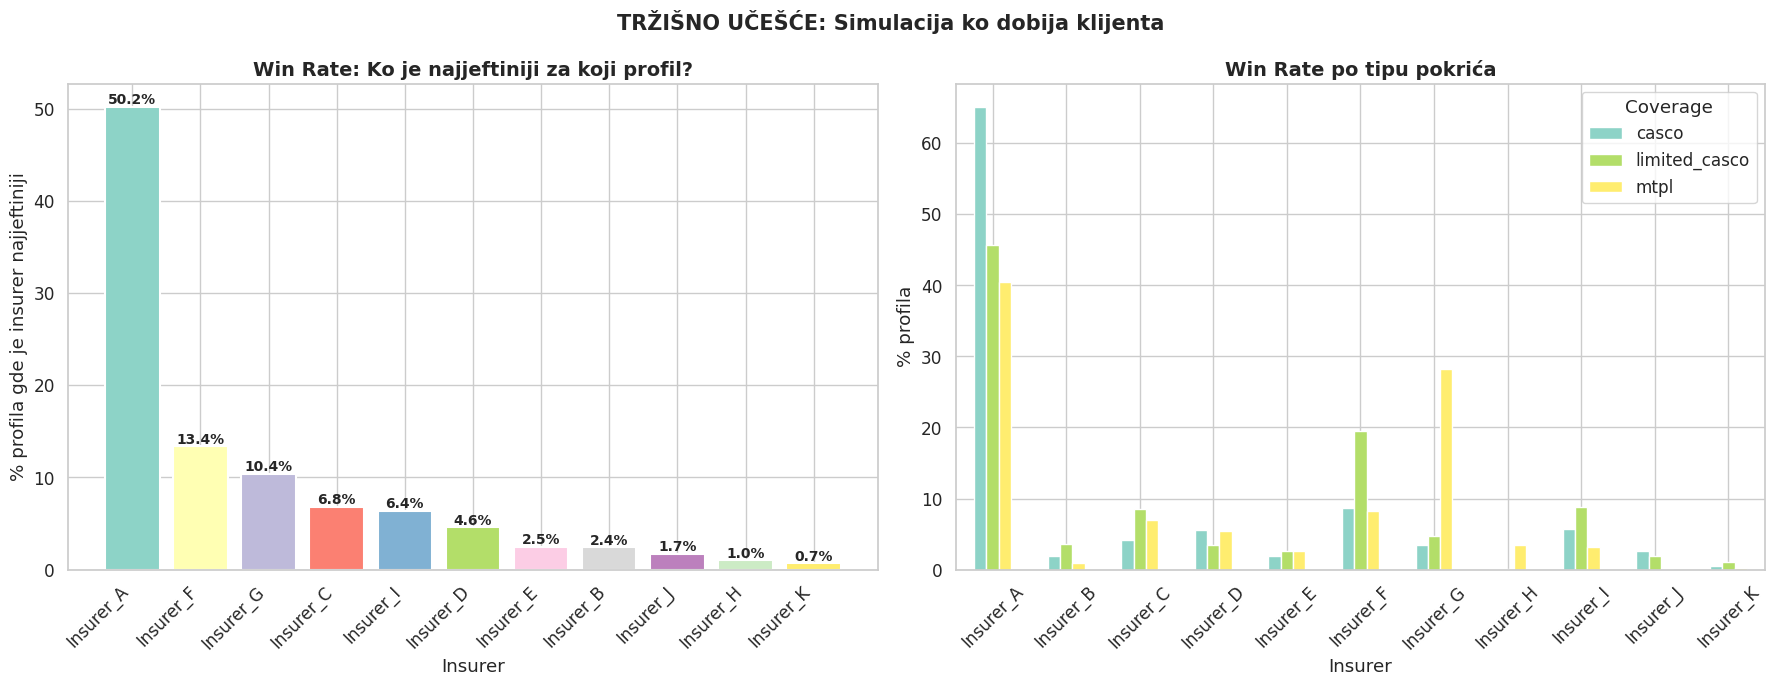

In [61]:

# ============================================================
# ANALIZA B — WIN RATE: Ko bi "pobedio" za svaki profil?
# ============================================================
print("=== ANALIZA B: WIN RATE ANALIZA ===")

# Za svaki red: ko je najjeftiniji (pobednik)?
price_matrix = df[insurer_cols].copy()
# Pobednik = insurer sa minimalnom cenom (ignorišemo NaN)
df['winner'] = price_matrix.idxmin(axis=1).str.replace('_price', '')
df['winner_price'] = price_matrix.min(axis=1)

win_rate = df['winner'].value_counts()
win_rate_pct = (win_rate / win_rate.sum() * 100).round(1)

# Win rate po coverage tipu
win_by_coverage = df.groupby(['coverage', 'winner']).size().unstack(fill_value=0)
win_by_coverage_pct = win_by_coverage.div(win_by_coverage.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Graf 1: Ukupni win rate
colors_w = plt.cm.Set3(np.linspace(0, 1, len(win_rate)))
bars = axes[0].bar(win_rate_pct.index, win_rate_pct.values, color=colors_w, edgecolor='white', linewidth=1.5)
axes[0].set_title('Win Rate: Ko je najjeftiniji za koji profil?', fontsize=14, fontweight='bold')
axes[0].set_ylabel('% profila gde je insurer najjeftiniji')
axes[0].set_xlabel('Insurer')
axes[0].set_xticklabels(
    axes[0].get_xticklabels(), 
    rotation=45, 
    ha='right'
)
for i, v in enumerate(win_rate_pct.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Graf 2: Win rate po coverage tipu (stacked bar)
win_by_coverage_pct.T.plot(kind='bar', ax=axes[1], colormap='Set3', edgecolor='white')
axes[1].set_title('Win Rate po tipu pokrića', fontsize=14, fontweight='bold')
axes[1].set_ylabel('% profila')
axes[1].set_xlabel('Insurer')
axes[1].legend(title='Coverage', loc='upper right')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('TRŽIŠNO UČEŠĆE: Simulacija ko dobija klijenta', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/B_win_rate.png', dpi=150, bbox_inches='tight')


print("Ukupni Win Rate:")
for ins, val in win_rate_pct.items():
    print(f"  {ins}: {val:.1f}% profila")

print("\nWin Rate po coverage tipu (%):")
print(win_by_coverage_pct.round(1).to_string())

print("✅ Analiza B gotova\n")

=== ANALIZA C: PRICE ELASTICITY (MARKET POWER) ===
Prosečna cena po broju ponuda:
 num_quotes_calc  avg_price  count
               0        NaN      0
               1 507.071531  15860
               2 206.953557  13315
               3 180.165104  13895
               4 160.705268  20712
               5 150.146992  28172
               6 146.000621  48423
               7 122.064670  84813
               8  86.259781 148851
               9  81.432190 103256
              10  78.608169  58371
              11  72.321767   3866

Korelacija (broj ponuda vs prosečna cena): -0.514
✅ Analiza C gotova

Prosečna cena po broju ponuda:
 num_quotes_calc  avg_price  count
               0        NaN      0
               1 507.071531  15860
               2 206.953557  13315
               3 180.165104  13895
               4 160.705268  20712
               5 150.146992  28172
               6 146.000621  48423
               7 122.064670  84813
               8  86.259781 148851
           

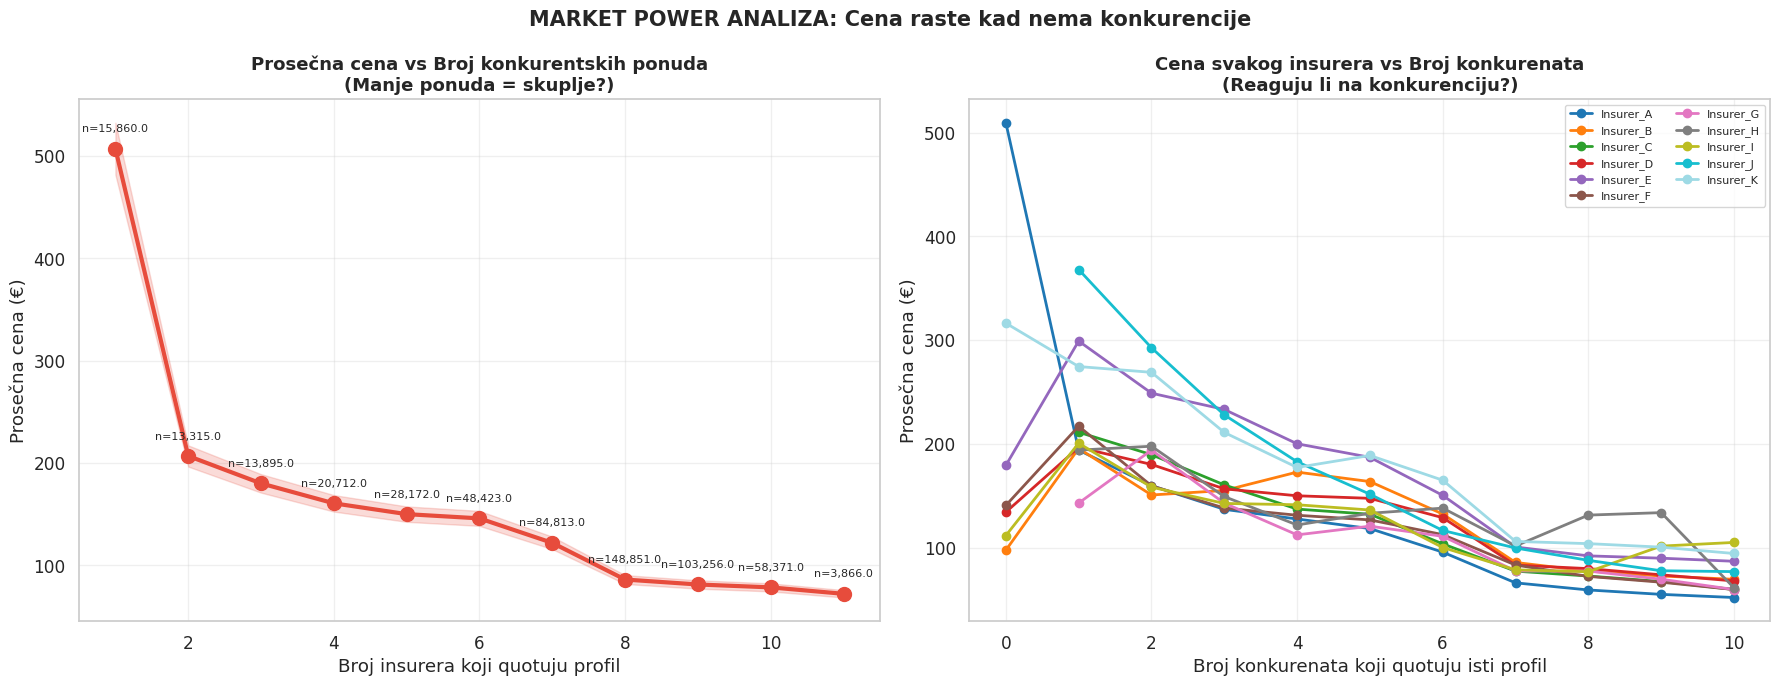

In [41]:

# ============================================================
# ANALIZA C — PRICE ELASTICITY: Manje konkurencije = više cene?
# ============================================================
print("=== ANALIZA C: PRICE ELASTICITY (MARKET POWER) ===")

# Za svaki profil: broj insurera koji quotuju + prosečna cena
df['num_quotes_calc'] = df[insurer_cols].notnull().sum(axis=1)
df['avg_quoted_price'] = df[insurer_cols].mean(axis=1)

# Grupisanje po broju ponuda
price_by_nquotes = df.groupby('num_quotes_calc').agg(
    avg_price=('avg_quoted_price', 'mean'),
    count=('avg_quoted_price', 'count'),
    median_price=('avg_quoted_price', 'median')
).reset_index()

# Isti insurer — kako mu se menja cena u zavisnosti od konkurencije?
insurer_price_by_competition = {}
for ins in insurer_cols:
    tmp = df[df[ins].notnull()].copy()
    tmp['competitors'] = tmp[insurer_cols].notnull().sum(axis=1) - 1  # -1 jer ne računamo sebe
    grouped = tmp.groupby('competitors')[ins].mean()
    insurer_price_by_competition[ins.replace('_price', '')] = grouped

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Graf 1: Prosečna cena vs broj ponuda
axes[0].plot(price_by_nquotes['num_quotes_calc'], price_by_nquotes['avg_price'],
             marker='o', linewidth=3, color='#e74c3c', markersize=10)
axes[0].fill_between(price_by_nquotes['num_quotes_calc'],
                     price_by_nquotes['avg_price'] * 0.95,
                     price_by_nquotes['avg_price'] * 1.05, alpha=0.2, color='#e74c3c')
for _, row in price_by_nquotes.iterrows():
    axes[0].annotate(f"n={row['count']:,}", (row['num_quotes_calc'], row['avg_price']),
                     textcoords='offset points', xytext=(0, 12), ha='center', fontsize=8)
axes[0].set_title('Prosečna cena vs Broj konkurentskih ponuda\n(Manje ponuda = skuplje?)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Broj insurera koji quotuju profil')
axes[0].set_ylabel('Prosečna cena (€)')
axes[0].grid(alpha=0.3)

# Graf 2: Kako svaki insurer menja cenu sa konkurencijom
colors_ins = plt.cm.tab20(np.linspace(0, 1, len(insurer_price_by_competition)))
for (ins, series), color in zip(insurer_price_by_competition.items(), colors_ins):
    if len(series) > 2:
        axes[1].plot(series.index, series.values, marker='o', label=ins, linewidth=2, color=color)
axes[1].set_title('Cena svakog insurera vs Broj konkurenata\n(Reaguju li na konkurenciju?)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Broj konkurenata koji quotuju isti profil')
axes[1].set_ylabel('Prosečna cena (€)')
axes[1].legend(loc='upper right', fontsize=8, ncol=2)
axes[1].grid(alpha=0.3)

plt.suptitle('MARKET POWER ANALIZA: Cena raste kad nema konkurencije', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/C_price_elasticity.png', dpi=150, bbox_inches='tight')


print("Prosečna cena po broju ponuda:")
print(price_by_nquotes[['num_quotes_calc', 'avg_price', 'count']].to_string(index=False))

# Korelacija: broj ponuda vs cena
corr = df[['num_quotes_calc', 'avg_quoted_price']].corr().iloc[0, 1]
print(f"\nKorelacija (broj ponuda vs prosečna cena): {corr:.3f}")
print("✅ Analiza C gotova\n")


=== ANALIZA D: BAD DRIVER × VEHICLE VALUE INTERACTION ===
Bad driver + luksuz (75k+): 251 profila
Bad driver + jeftino (<10k): 199 profila
Good driver + luksuz (75k+): 31,324 profila

Quote Rate po segmentu (%):
                     Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
Bad+Luksuz\n(75k+)        99.2       12.4       70.1        1.6       13.9       47.0        1.2        0.0       29.9       23.5        8.8
Bad+Jeftino\n(<10k)      100.0        1.0       69.8       45.7       65.3       36.7       41.7       35.2        4.0       48.2       41.2
Good+Luksuz\n(75k+)       98.2       28.9       71.5       54.6       30.7       61.5       14.1        5.9       25.2       27.1       33.8

Prosečna cena po segmentu (€):
                     Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
Bad+Luksuz\n(75k+)       197.0      516.0      241.

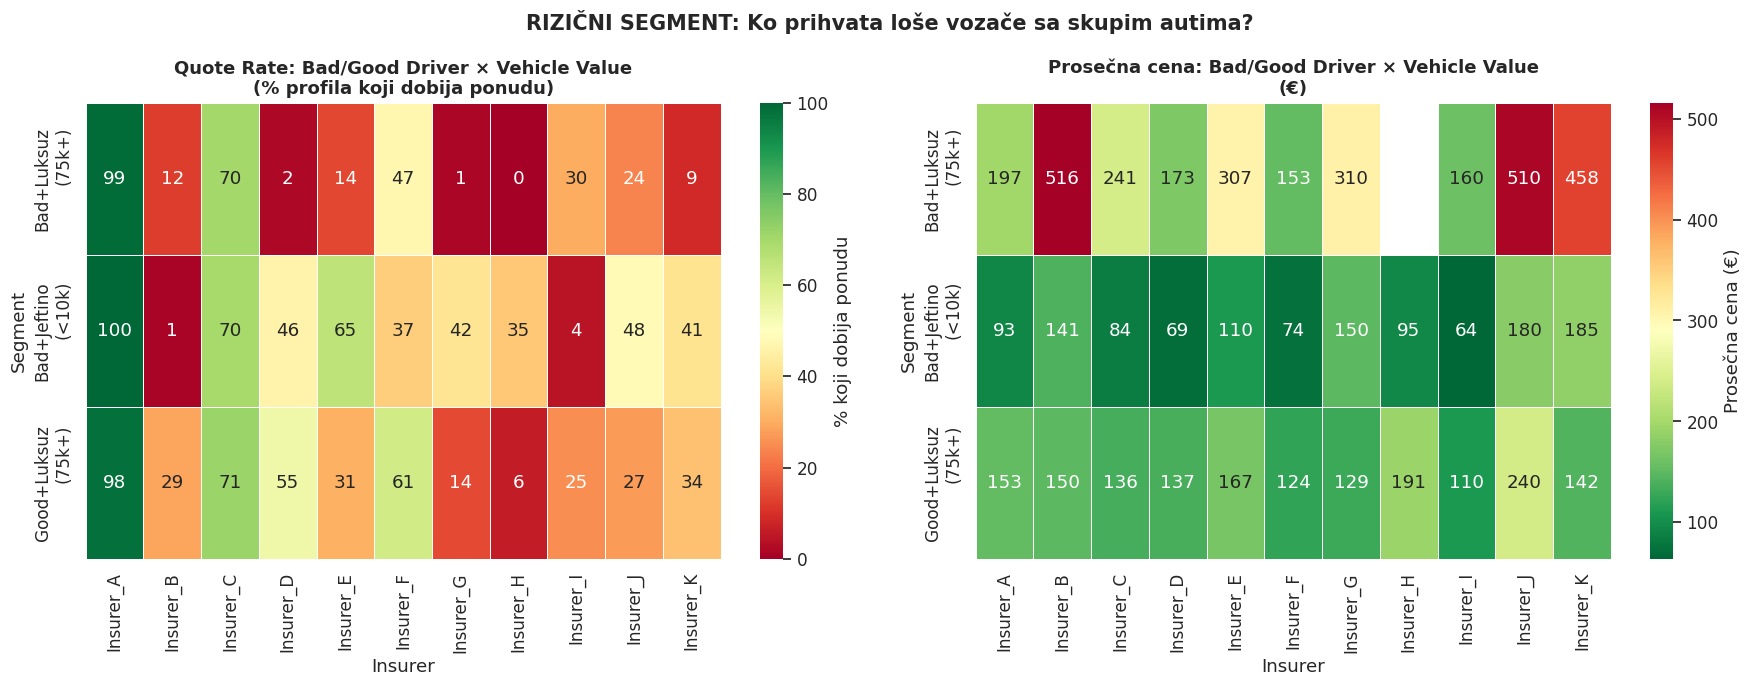

In [42]:

# ============================================================
# ANALIZA D — INTERACTION: Bad Driver × Vehicle Value
# ============================================================
print("=== ANALIZA D: BAD DRIVER × VEHICLE VALUE INTERACTION ===")

# Ko prihvata loše vozače sa skupim autima?
bad_luxury = df[(df['is_bad_driver'] == 1) & (df['vehicle_value_group'] == '75k+')]
bad_cheap  = df[(df['is_bad_driver'] == 1) & (df['vehicle_value_group'] == '<10k')]
good_luxury = df[(df['is_bad_driver'] == 0) & (df['vehicle_value_group'] == '75k+')]

print(f"Bad driver + luksuz (75k+): {len(bad_luxury):,} profila")
print(f"Bad driver + jeftino (<10k): {len(bad_cheap):,} profila")
print(f"Good driver + luksuz (75k+): {len(good_luxury):,} profila")

# Quote rate za svaku kombinaciju
segments = {
    'Bad+Luksuz\n(75k+)': bad_luxury,
    'Bad+Jeftino\n(<10k)': bad_cheap,
    'Good+Luksuz\n(75k+)': good_luxury,
}

quote_rates = {}
avg_prices = {}
for seg_name, seg_df in segments.items():
    qr = {}
    ap = {}
    for ins in insurer_cols:
        ins_name = ins.replace('_price', '')
        qr[ins_name] = seg_df[ins].notnull().mean() * 100
        ap[ins_name] = seg_df[ins].mean()
    quote_rates[seg_name] = qr
    avg_prices[seg_name] = ap

qr_df = pd.DataFrame(quote_rates)
ap_df = pd.DataFrame(avg_prices)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Graf 1: Quote rate heatmap
sns.heatmap(qr_df.T, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': '% koji dobija ponudu'})
axes[0].set_title('Quote Rate: Bad/Good Driver × Vehicle Value\n(% profila koji dobija ponudu)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Insurer')
axes[0].set_ylabel('Segment')

# Graf 2: Prosečna cena heatmap
sns.heatmap(ap_df.T, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Prosečna cena (€)'})
axes[1].set_title('Prosečna cena: Bad/Good Driver × Vehicle Value\n(€)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Insurer')
axes[1].set_ylabel('Segment')

plt.suptitle('RIZIČNI SEGMENT: Ko prihvata loše vozače sa skupim autima?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/D_bad_driver_luxury.png', dpi=150, bbox_inches='tight')


print("\nQuote Rate po segmentu (%):")
print(qr_df.T.round(1).to_string())
print("\nProsečna cena po segmentu (€):")
print(ap_df.T.round(0).to_string())
print("✅ Analiza D gotova\n")

In [43]:

# ============================================================
# ANALIZA E — SECOND DRIVER EFFECT
# ============================================================
print("=== ANALIZA E: SECOND DRIVER EFFECT ===")

has_2nd = df[df['has_second_driver'] == 1]
no_2nd  = df[df['has_second_driver'] == 0]

print(f"Profili sa 2. vozačem: {len(has_2nd):,} ({len(has_2nd)/len(df)*100:.1f}%)")
print(f"Profili bez 2. vozača: {len(no_2nd):,} ({len(no_2nd)/len(df)*100:.1f}%)")

# Razlika u ceni: sa vs bez 2. vozača
price_diff_2nd = {}
quote_diff_2nd = {}
for ins in insurer_cols:
    ins_name = ins.replace('_price', '')
    p_with = has_2nd[ins].mean()
    p_without = no_2nd[ins].mean()
    q_with = has_2nd[ins].notnull().mean() * 100
    q_without = no_2nd[ins].notnull().mean() * 100
    price_diff_2nd[ins_name] = {
        'with': p_with, 'without': p_without,
        'diff_pct': (p_with - p_without) / p_without * 100
    }
    quote_diff_2nd[ins_name] = {
        'with': q_with, 'without': q_without,
        'diff': q_with - q_without
    }

price_diff_df = pd.DataFrame(price_diff_2nd).T
quote_diff_df = pd.DataFrame(quote_diff_2nd).T

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Graf 1: % razlika u ceni
colors_2nd = ['#e74c3c' if v > 5 else '#2ecc71' if v < -5 else '#e67e22'
              for v in price_diff_df['diff_pct'].values]
axes[0].bar(price_diff_df.index, price_diff_df['diff_pct'].values, color=colors_2nd, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('% razlika u ceni: Sa vs Bez 2. vozača\n(pozitivno = skuplje sa 2. vozačem)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('% razlika u ceni')
for i, v in enumerate(price_diff_df['diff_pct'].values):
    axes[0].text(i, v + (0.3 if v >= 0 else -1.2), f'{v:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# Graf 2: Quote rate razlika
colors_q2 = ['#e74c3c' if v < -5 else '#2ecc71' if v > 5 else '#e67e22'
             for v in quote_diff_df['diff'].values]
axes[1].bar(quote_diff_df.index, quote_diff_df['diff'].values, color=colors_q2, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Razlika u quote rate: Sa vs Bez 2. vozača\n(negativno = manje ponuda sa 2. vozačem)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Razlika u quote rate (pp)')
for i, v in enumerate(quote_diff_df['diff'].values):
    axes[1].text(i, v + (0.3 if v >= 0 else -0.8), f'{v:+.1f}pp',
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('DRUGI VOZAČ: Ko ga kažnjava, ko ignoriše?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/E_second_driver.png', dpi=150, bbox_inches='tight')
plt.close()

print("\nEfekat 2. vozača na cenu:")
for ins, row in price_diff_df.iterrows():
    print(f"  {ins}: sa 2.voz={row['with']:.0f}€, bez={row['without']:.0f}€, razlika={row['diff_pct']:+.1f}%")

print("\nEfekat 2. vozača na quote rate:")
for ins, row in quote_diff_df.iterrows():
    print(f"  {ins}: sa 2.voz={row['with']:.1f}%, bez={row['without']:.1f}%, razlika={row['diff']:+.1f}pp")
print("✅ Analiza E gotova\n")

=== ANALIZA E: SECOND DRIVER EFFECT ===
Profili sa 2. vozačem: 0 (0.0%)
Profili bez 2. vozača: 541,292 (100.0%)
Profili sa 2. vozačem: 0 (0.0%)
Profili bez 2. vozača: 541,292 (100.0%)


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos


Efekat 2. vozača na cenu:
  Insurer_A: sa 2.voz=nan€, bez=97€, razlika=+nan%
  Insurer_B: sa 2.voz=nan€, bez=100€, razlika=+nan%
  Insurer_C: sa 2.voz=nan€, bez=89€, razlika=+nan%
  Insurer_D: sa 2.voz=nan€, bez=98€, razlika=+nan%
  Insurer_E: sa 2.voz=nan€, bez=116€, razlika=+nan%
  Insurer_F: sa 2.voz=nan€, bez=97€, razlika=+nan%
  Insurer_G: sa 2.voz=nan€, bez=85€, razlika=+nan%
  Insurer_H: sa 2.voz=nan€, bez=116€, razlika=+nan%
  Insurer_I: sa 2.voz=nan€, bez=95€, razlika=+nan%
  Insurer_J: sa 2.voz=nan€, bez=105€, razlika=+nan%
  Insurer_K: sa 2.voz=nan€, bez=124€, razlika=+nan%

Efekat 2. vozača na quote rate:
  Insurer_A: sa 2.voz=nan%, bez=97.4%, razlika=+nanpp
  Insurer_B: sa 2.voz=nan%, bez=80.5%, razlika=+nanpp
  Insurer_C: sa 2.voz=nan%, bez=79.6%, razlika=+nanpp
  Insurer_D: sa 2.voz=nan%, bez=74.5%, razlika=+nanpp
  Insurer_E: sa 2.voz=nan%, bez=74.4%, razlika=+nanpp
  Insurer_F: sa 2.voz=nan%, bez=66.1%, razlika=+nanpp
  Insurer_G: sa 2.voz=nan%, bez=58.1%, razlika=+na

=== ANALIZA F: PAYMENT FREQUENCY PREMIUM ===
Payment frequency distribucija:
payment_frequency
monthly    529806
yearly      11486
Name: count, dtype: int64

Prosečna cena po payment frequency:
                   Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
payment_frequency                                                                                                                         
monthly                 86.0      100.0       89.0       98.0      116.0       97.0       85.0      116.0       95.0      105.0      124.0
yearly                 677.0        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN
✅ Analiza F gotova


Prosečna cena po payment frequency:
                   Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
payment_frequency                                     

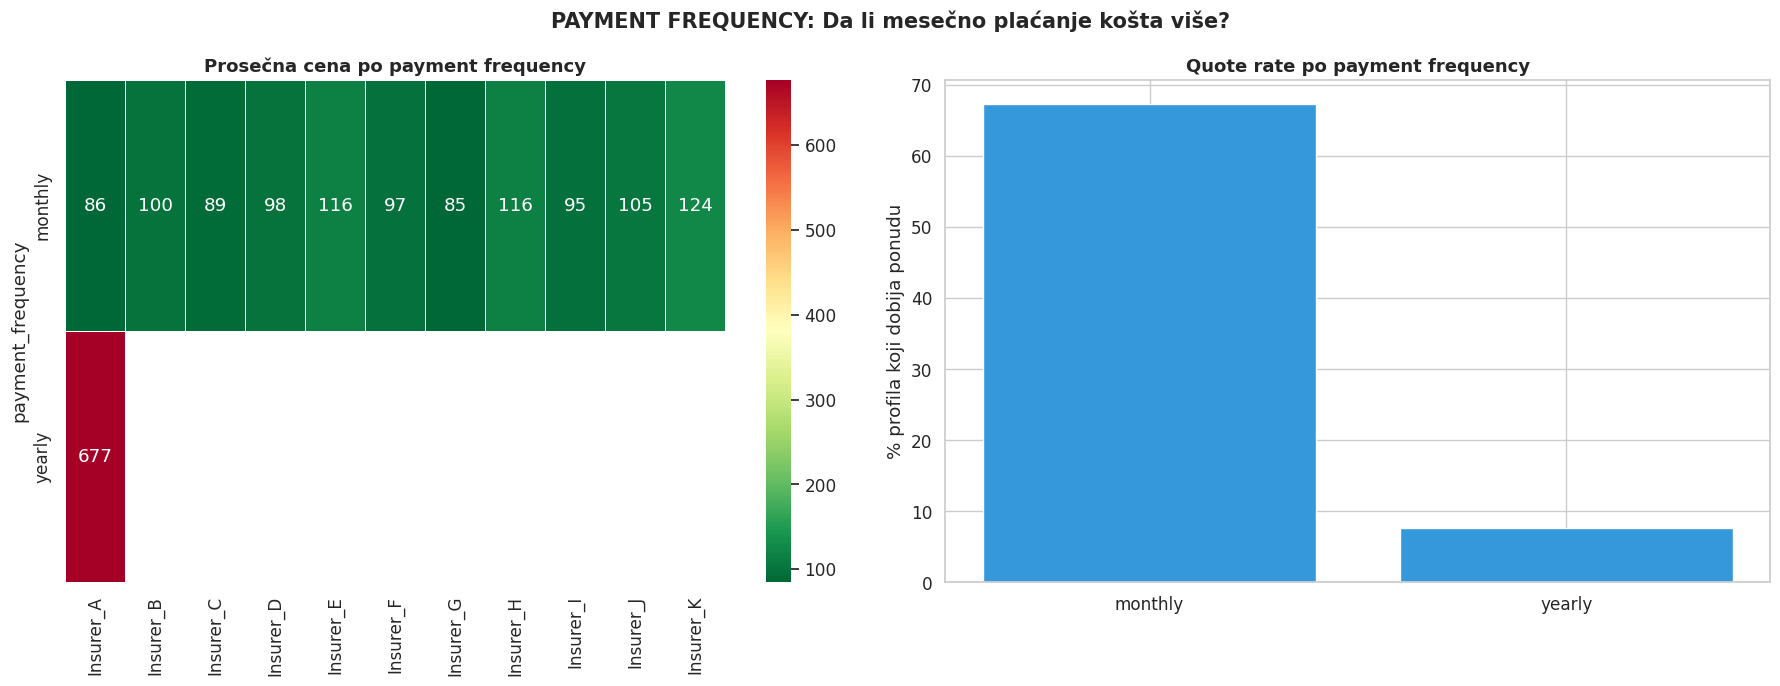

In [44]:

# ============================================================
# ANALIZA F — PAYMENT FREQUENCY PREMIUM
# ============================================================
print("=== ANALIZA F: PAYMENT FREQUENCY PREMIUM ===")

print("Payment frequency distribucija:")
print(df['payment_frequency'].value_counts())

if df['payment_frequency'].nunique() > 1:
    freq_prices = df.groupby('payment_frequency')[insurer_cols].mean()
    freq_prices.columns = [c.replace('_price', '') for c in freq_prices.columns]
    freq_quote  = df.groupby('payment_frequency')[insurer_cols].apply(
        lambda x: x.notnull().mean() * 100).mean(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Heatmap cena
    sns.heatmap(freq_prices, annot=True, fmt='.0f', cmap='RdYlGn_r',
                linewidths=0.5, ax=axes[0])
    axes[0].set_title('Prosečna cena po payment frequency', fontsize=13, fontweight='bold')

    # Quote rate
    axes[1].bar(freq_quote.index.astype(str), freq_quote.values, color='#3498db', edgecolor='white')
    axes[1].set_title('Quote rate po payment frequency', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('% profila koji dobija ponudu')

    plt.suptitle('PAYMENT FREQUENCY: Da li mesečno plaćanje košta više?', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/F_payment_frequency.png', dpi=150, bbox_inches='tight')


    print("\nProsečna cena po payment frequency:")
    print(freq_prices.round(0).to_string())
else:
    print("Samo jedna payment frequency vrednost — preskačem vizualizaciju")
print("✅ Analiza F gotova\n")

=== ANALIZA G: MARKET CONCENTRATION (HHI) ===
HHI po coverage tipu:
  casco: 4424 (VISOKA koncentracija)
  limited_casco: 2676 (VISOKA koncentracija)
  mtpl: 2616 (VISOKA koncentracija)

HHI po vrednosti vozila:
  35-50k: 3701 (VISOKA koncentracija)
  50-75k: 3540 (VISOKA koncentracija)
  20-35k: 2910 (VISOKA koncentracija)
  75k+: 2795 (VISOKA koncentracija)
  10-20k: 2465 (UMERENA koncentracija)
  <10k: 2145 (UMERENA koncentracija)

HHI po starosti vozača:
  45-55: 3298 (VISOKA koncentracija)
  55-65: 3273 (VISOKA koncentracija)
  25-35: 3166 (VISOKA koncentracija)
  35-45: 3013 (VISOKA koncentracija)
  <25: 2946 (VISOKA koncentracija)
  65+: 2594 (VISOKA koncentracija)
✅ Analiza G gotova

HHI po coverage tipu:
  casco: 4424 (VISOKA koncentracija)
  limited_casco: 2676 (VISOKA koncentracija)
  mtpl: 2616 (VISOKA koncentracija)

HHI po vrednosti vozila:
  35-50k: 3701 (VISOKA koncentracija)
  50-75k: 3540 (VISOKA koncentracija)
  20-35k: 2910 (VISOKA koncentracija)
  75k+: 2795 (VISOK

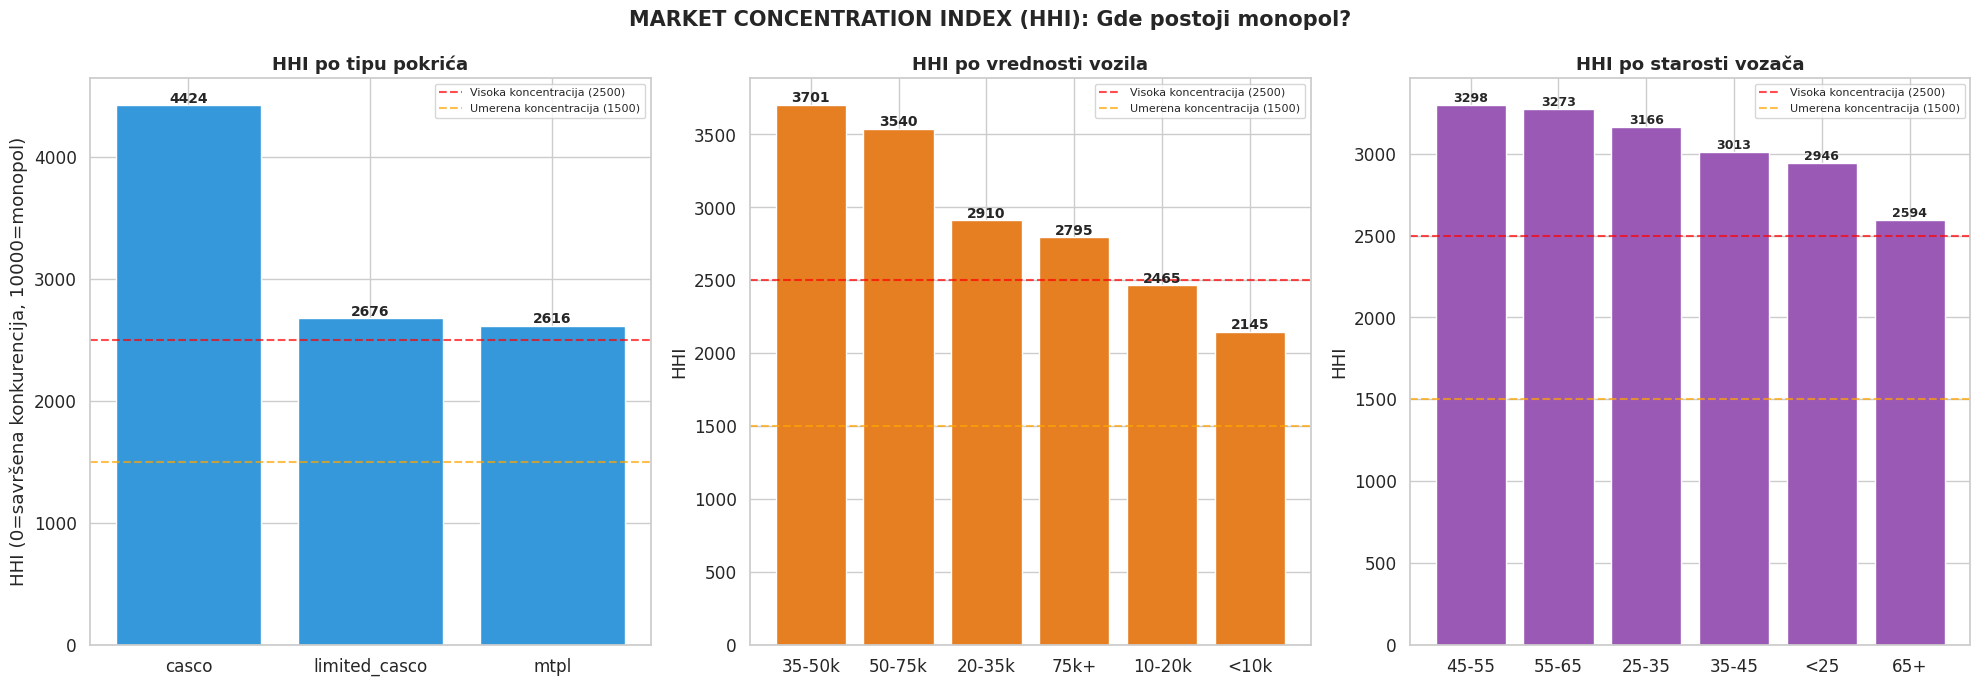

In [45]:

# ============================================================
# ANALIZA G — MARKET CONCENTRATION (HHI) PO SEGMENTU
# ============================================================
print("=== ANALIZA G: MARKET CONCENTRATION (HHI) ===")

# HHI = sum of squared market shares (0-10000)
# Visok HHI = monopol, nizak = konkurentno tržište

def calc_hhi(group):
    """Herfindahl-Hirschman Index za grupu"""
    wins = group['winner'].value_counts()
    shares = wins / wins.sum()
    return (shares ** 2).sum() * 10000

# HHI po coverage tipu
hhi_coverage = df.groupby('coverage').apply(calc_hhi).sort_values(ascending=False)

# HHI po vehicle value grupi
hhi_value = df.groupby('vehicle_value_group', observed=True).apply(calc_hhi).sort_values(ascending=False)

# HHI po age grupi
df_with_age = df[df['age_group'].notna()]
hhi_age = df_with_age.groupby('age_group', observed=True).apply(calc_hhi).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Referentne linije HHI
def add_hhi_refs(ax):
    ax.axhline(2500, color='red', linestyle='--', alpha=0.7, label='Visoka koncentracija (2500)')
    ax.axhline(1500, color='orange', linestyle='--', alpha=0.7, label='Umerena koncentracija (1500)')

axes[0].bar(hhi_coverage.index, hhi_coverage.values, color='#3498db', edgecolor='white')
add_hhi_refs(axes[0])
axes[0].set_title('HHI po tipu pokrića', fontsize=13, fontweight='bold')
axes[0].set_ylabel('HHI (0=savršena konkurencija, 10000=monopol)')
axes[0].legend(fontsize=8)
for i, v in enumerate(hhi_coverage.values):
    axes[0].text(i, v + 20, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(hhi_value.index.astype(str), hhi_value.values, color='#e67e22', edgecolor='white')
add_hhi_refs(axes[1])
axes[1].set_title('HHI po vrednosti vozila', fontsize=13, fontweight='bold')
axes[1].set_ylabel('HHI')
axes[1].legend(fontsize=8)
for i, v in enumerate(hhi_value.values):
    axes[1].text(i, v + 20, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

axes[2].bar(hhi_age.index.astype(str), hhi_age.values, color='#9b59b6', edgecolor='white')
add_hhi_refs(axes[2])
axes[2].set_title('HHI po starosti vozača', fontsize=13, fontweight='bold')
axes[2].set_ylabel('HHI')
axes[2].legend(fontsize=8)
for i, v in enumerate(hhi_age.values):
    axes[2].text(i, v + 20, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('MARKET CONCENTRATION INDEX (HHI): Gde postoji monopol?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/G_hhi_concentration.png', dpi=150, bbox_inches='tight')


print("HHI po coverage tipu:")
for seg, val in hhi_coverage.items():
    level = "VISOKA" if val > 2500 else "UMERENA" if val > 1500 else "NISKA"
    print(f"  {seg}: {val:.0f} ({level} koncentracija)")

print("\nHHI po vrednosti vozila:")
for seg, val in hhi_value.items():
    level = "VISOKA" if val > 2500 else "UMERENA" if val > 1500 else "NISKA"
    print(f"  {seg}: {val:.0f} ({level} koncentracija)")

print("\nHHI po starosti vozača:")
for seg, val in hhi_age.items():
    level = "VISOKA" if val > 2500 else "UMERENA" if val > 1500 else "NISKA"
    print(f"  {seg}: {val:.0f} ({level} koncentracija)")
print("✅ Analiza G gotova\n")

=== ANALIZA H: VEHICLE INSPECTION DEFICIENCIES ===
Vozila sa defektima: 318,324 (58.8%)
Distribucija broja defekata:
insp_deficiencies
1.0    318324
Name: count, dtype: int64

Efekat defekta na cenu (% skuplje):
  Insurer_I: +0.8%
  Insurer_K: -4.3%
  Insurer_E: -5.2%
  Insurer_F: -7.0%
  Insurer_B: -12.9%
  Insurer_D: -13.4%
  Insurer_A: -14.4%
  Insurer_H: -16.4%
  Insurer_G: -17.8%
  Insurer_J: -18.5%
  Insurer_C: -23.6%

Efekat defekta na quote rate (pp):
  Insurer_J: -13.0pp
  Insurer_C: -6.2pp
  Insurer_F: -4.1pp
  Insurer_D: -3.7pp
  Insurer_B: -3.2pp
  Insurer_I: -1.3pp
  Insurer_A: +1.7pp
  Insurer_G: +8.5pp
  Insurer_K: +10.0pp
  Insurer_H: +11.0pp
  Insurer_E: +12.0pp
✅ Analiza H gotova


Efekat defekta na cenu (% skuplje):
  Insurer_I: +0.8%
  Insurer_K: -4.3%
  Insurer_E: -5.2%
  Insurer_F: -7.0%
  Insurer_B: -12.9%
  Insurer_D: -13.4%
  Insurer_A: -14.4%
  Insurer_H: -16.4%
  Insurer_G: -17.8%
  Insurer_J: -18.5%
  Insurer_C: -23.6%

Efekat defekta na quote rate (pp):
  I

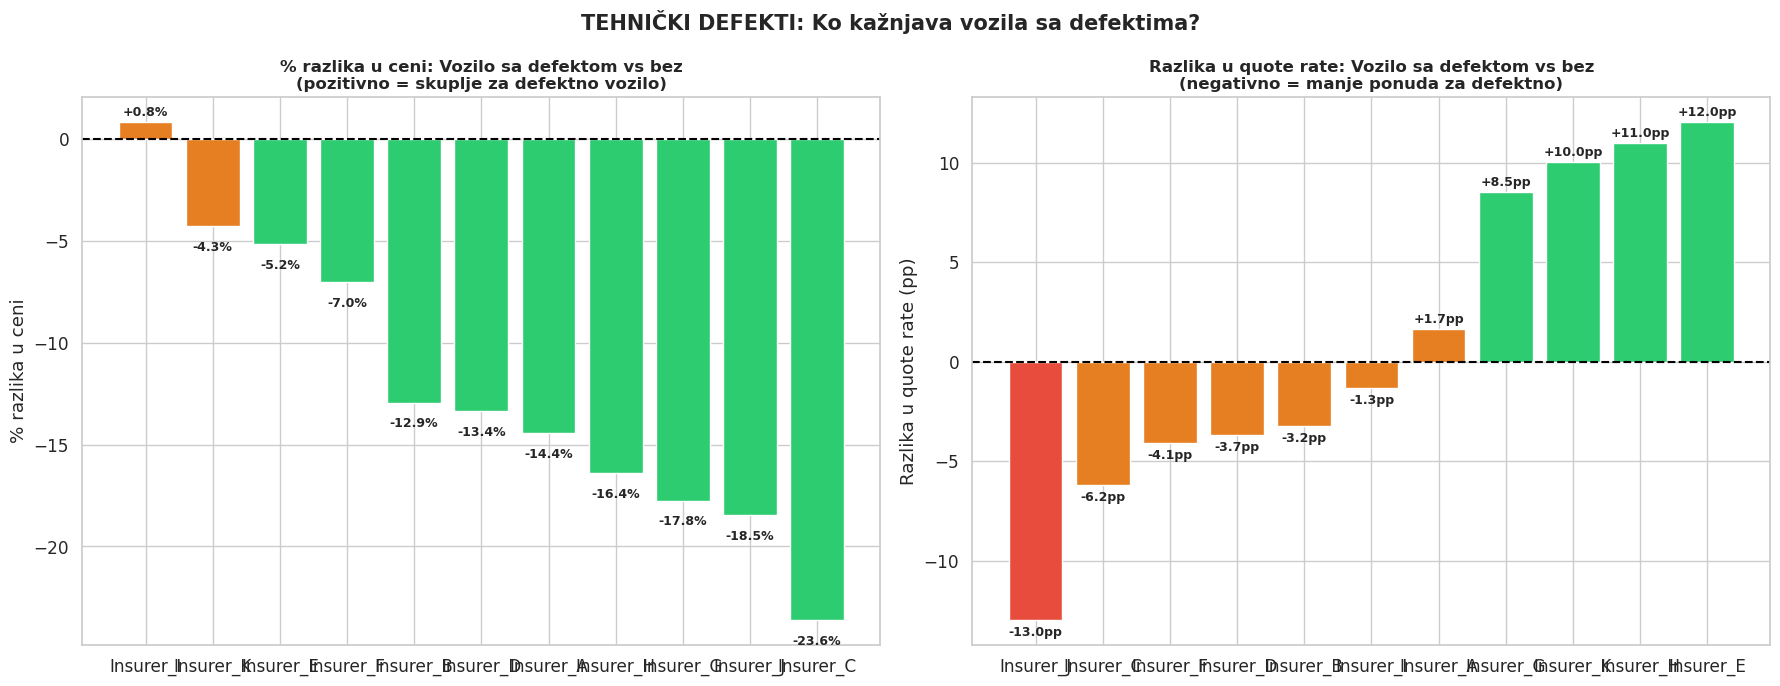

In [46]:

# ============================================================
# ANALIZA H — VEHICLE INSPECTION DEFICIENCIES
# ============================================================
print("=== ANALIZA H: VEHICLE INSPECTION DEFICIENCIES ===")

df['insp_deficiencies'] = pd.to_numeric(df['vehicle_inspection_number_of_deficiencies_found'], errors='coerce')
df['has_deficiency'] = (df['insp_deficiencies'] > 0).astype(int)

print(f"Vozila sa defektima: {df['has_deficiency'].sum():,} ({df['has_deficiency'].mean()*100:.1f}%)")
print(f"Distribucija broja defekata:\n{df['insp_deficiencies'].value_counts().head(10)}")

no_def  = df[df['has_deficiency'] == 0]
has_def = df[df['has_deficiency'] == 1]

def_price_diff = {}
def_quote_diff = {}
for ins in insurer_cols:
    ins_name = ins.replace('_price', '')
    p_no  = no_def[ins].mean()
    p_has = has_def[ins].mean()
    q_no  = no_def[ins].notnull().mean() * 100
    q_has = has_def[ins].notnull().mean() * 100
    def_price_diff[ins_name] = (p_has - p_no) / p_no * 100 if p_no > 0 else 0
    def_quote_diff[ins_name] = q_has - q_no

def_price_s = pd.Series(def_price_diff).sort_values(ascending=False)
def_quote_s = pd.Series(def_quote_diff).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors_def = ['#e74c3c' if v > 10 else '#2ecc71' if v < -5 else '#e67e22'
              for v in def_price_s.values]
axes[0].bar(def_price_s.index, def_price_s.values, color=colors_def, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('% razlika u ceni: Vozilo sa defektom vs bez\n(pozitivno = skuplje za defektno vozilo)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('% razlika u ceni')
for i, v in enumerate(def_price_s.values):
    axes[0].text(i, v + (0.3 if v >= 0 else -1.2), f'{v:+.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

colors_qdef = ['#e74c3c' if v < -10 else '#2ecc71' if v > 5 else '#e67e22'
               for v in def_quote_s.values]
axes[1].bar(def_quote_s.index, def_quote_s.values, color=colors_qdef, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Razlika u quote rate: Vozilo sa defektom vs bez\n(negativno = manje ponuda za defektno)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Razlika u quote rate (pp)')
for i, v in enumerate(def_quote_s.values):
    axes[1].text(i, v + (0.3 if v >= 0 else -0.8), f'{v:+.1f}pp',
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('TEHNIČKI DEFEKTI: Ko kažnjava vozila sa defektima?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/H_inspection_defects.png', dpi=150, bbox_inches='tight')


print("\nEfekat defekta na cenu (% skuplje):")
for ins, val in def_price_s.items():
    print(f"  {ins}: {val:+.1f}%")
print("\nEfekat defekta na quote rate (pp):")
for ins, val in def_quote_s.items():
    print(f"  {ins}: {val:+.1f}pp")
print("✅ Analiza H gotova\n")

=== ANALIZA I: USAGE TYPE ANALIZA ===
Usage type distribucija:
usage
private_use    541292
Name: count, dtype: int64

Prosečna cena po usage tipu:
             Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
usage                                                                                                                               
private_use       97.0      100.0       89.0       98.0      116.0       97.0       85.0      116.0       95.0      105.0      124.0

Quote rate po usage tipu:
usage
private_use    66.1
dtype: float64
✅ Analiza I gotova


Prosečna cena po usage tipu:
             Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
usage                                                                                                                               
private_use       97.0      100.0       89.0       98.0      116.0    

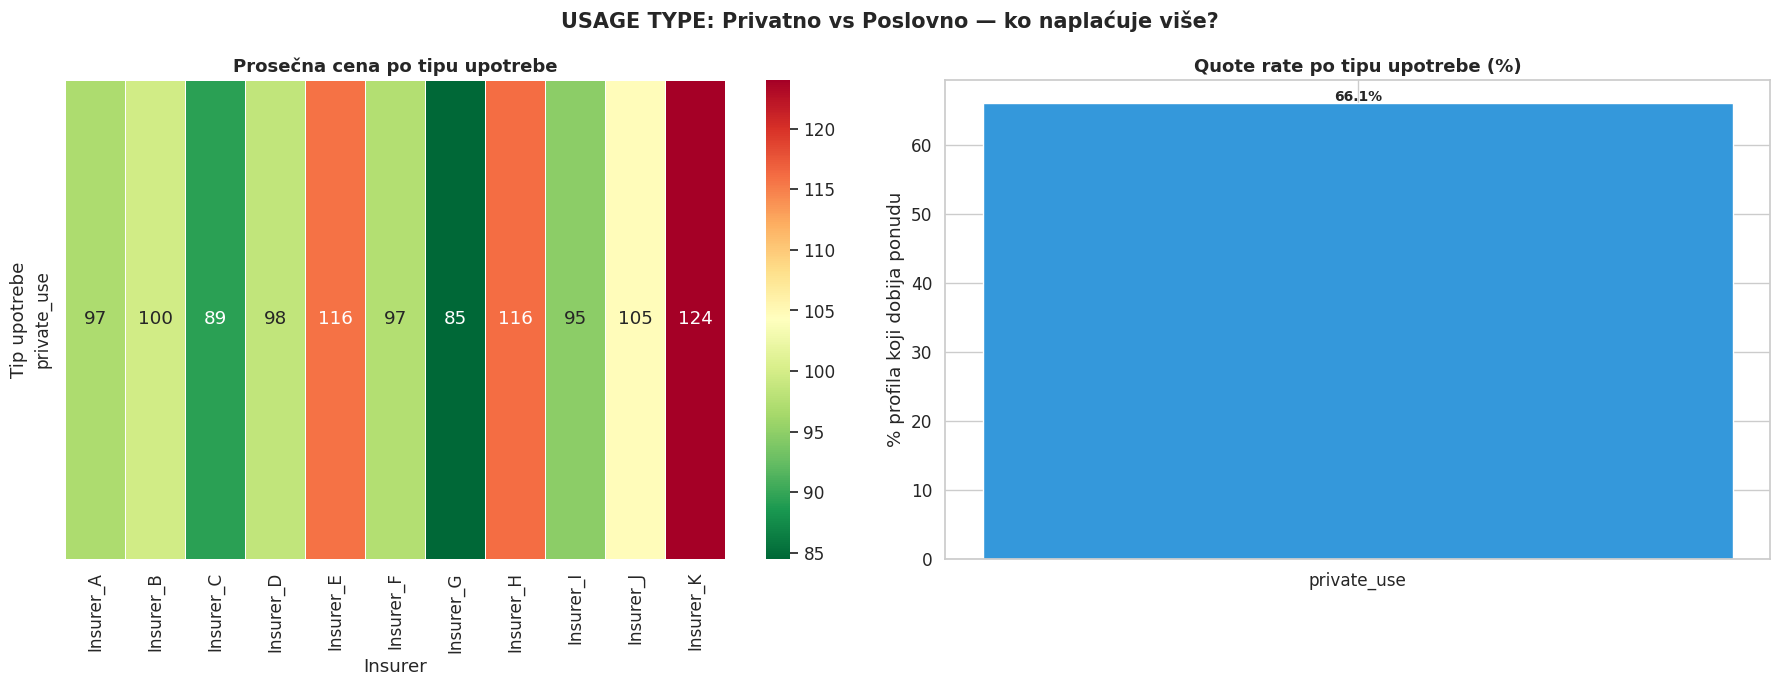

In [47]:

# ============================================================
# ANALIZA I — USAGE TYPE (Private vs Business vs Other)
# ============================================================
print("=== ANALIZA I: USAGE TYPE ANALIZA ===")

print("Usage type distribucija:")
print(df['usage'].value_counts())

usage_prices = df.groupby('usage')[insurer_cols].mean()
usage_prices.columns = [c.replace('_price', '') for c in usage_prices.columns]
usage_quote = df.groupby('usage')[insurer_cols].apply(
    lambda x: x.notnull().mean() * 100).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(usage_prices, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Prosečna cena po tipu upotrebe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Insurer')
axes[0].set_ylabel('Tip upotrebe')

axes[1].bar(usage_quote.index.astype(str), usage_quote.values, color='#3498db', edgecolor='white')
axes[1].set_title('Quote rate po tipu upotrebe (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% profila koji dobija ponudu')
for i, v in enumerate(usage_quote.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('USAGE TYPE: Privatno vs Poslovno — ko naplaćuje više?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/I_usage_type.png', dpi=150, bbox_inches='tight')


print("\nProsečna cena po usage tipu:")
print(usage_prices.round(0).to_string())
print("\nQuote rate po usage tipu:")
print(usage_quote.round(1))
print("✅ Analiza I gotova\n")

=== ANALIZA I: USAGE TYPE ANALIZA ===
Usage type distribucija:
usage
private_use    541292
Name: count, dtype: int64

Prosečna cena po usage tipu:
             Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
usage                                                                                                                               
private_use       97.0      100.0       89.0       98.0      116.0       97.0       85.0      116.0       95.0      105.0      124.0

Quote rate po usage tipu:
usage
private_use    66.1
dtype: float64
✅ Analiza I gotova


Prosečna cena po usage tipu:
             Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
usage                                                                                                                               
private_use       97.0      100.0       89.0       98.0      116.0    

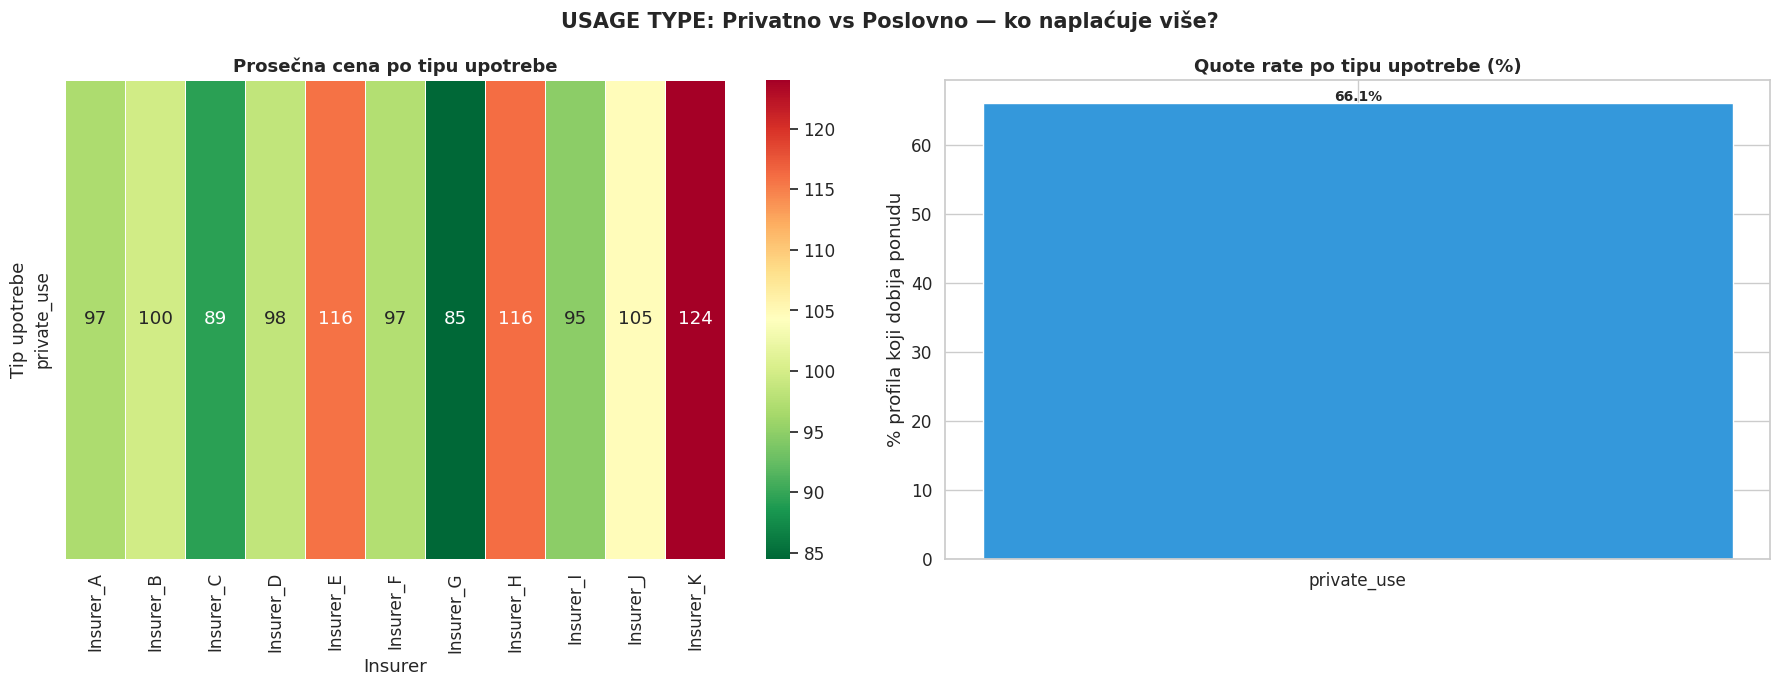

In [48]:

# ============================================================
# ANALIZA I — USAGE TYPE (Private vs Business vs Other)
# ============================================================
print("=== ANALIZA I: USAGE TYPE ANALIZA ===")

print("Usage type distribucija:")
print(df['usage'].value_counts())

usage_prices = df.groupby('usage')[insurer_cols].mean()
usage_prices.columns = [c.replace('_price', '') for c in usage_prices.columns]
usage_quote = df.groupby('usage')[insurer_cols].apply(
    lambda x: x.notnull().mean() * 100).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(usage_prices, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Prosečna cena po tipu upotrebe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Insurer')
axes[0].set_ylabel('Tip upotrebe')

axes[1].bar(usage_quote.index.astype(str), usage_quote.values, color='#3498db', edgecolor='white')
axes[1].set_title('Quote rate po tipu upotrebe (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% profila koji dobija ponudu')
for i, v in enumerate(usage_quote.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('USAGE TYPE: Privatno vs Poslovno — ko naplaćuje više?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/I_usage_type.png', dpi=150, bbox_inches='tight')


print("\nProsečna cena po usage tipu:")
print(usage_prices.round(0).to_string())
print("\nQuote rate po usage tipu:")
print(usage_quote.round(1))
print("✅ Analiza I gotova\n")

=== ANALIZA J: GEOGRAPHIC HOTSPOTS ===
Top 10 najskupljih provincija (prosečna tržišna cena):
  Province_12: 117€
  Province_8: 108€
  Province_10: 104€
  Province_2: 98€
  Province_7: 98€
  Province_6: 98€
  Province_9: 93€
  Province_5: 93€
  Province_4: 92€
  Province_11: 85€

Top 10 najjeftinijih provincija:
  Province_1: 77€
  Province_3: 77€
  Province_11: 85€
  Province_4: 92€
  Province_5: 93€
  Province_9: 93€
  Province_6: 98€
  Province_7: 98€
  Province_2: 98€
  Province_10: 104€

Korelacija crime rate vs cena:
  Insurer_I: r=0.115
  Insurer_H: r=0.114
  Insurer_G: r=0.112
  Insurer_C: r=0.109
  Insurer_D: r=0.087
  Insurer_E: r=0.084
  Insurer_B: r=0.083
  Insurer_K: r=0.080
  Insurer_J: r=0.080
  Insurer_F: r=0.074
  Insurer_A: r=0.044

Korelacija property value vs cena:
  Insurer_H: r=0.059
  Insurer_A: r=0.027
  Insurer_J: r=0.020
  Insurer_K: r=-0.025
  Insurer_C: r=-0.035
  Insurer_G: r=-0.039
  Insurer_B: r=-0.053
  Insurer_E: r=-0.056
  Insurer_D: r=-0.064
  Insurer

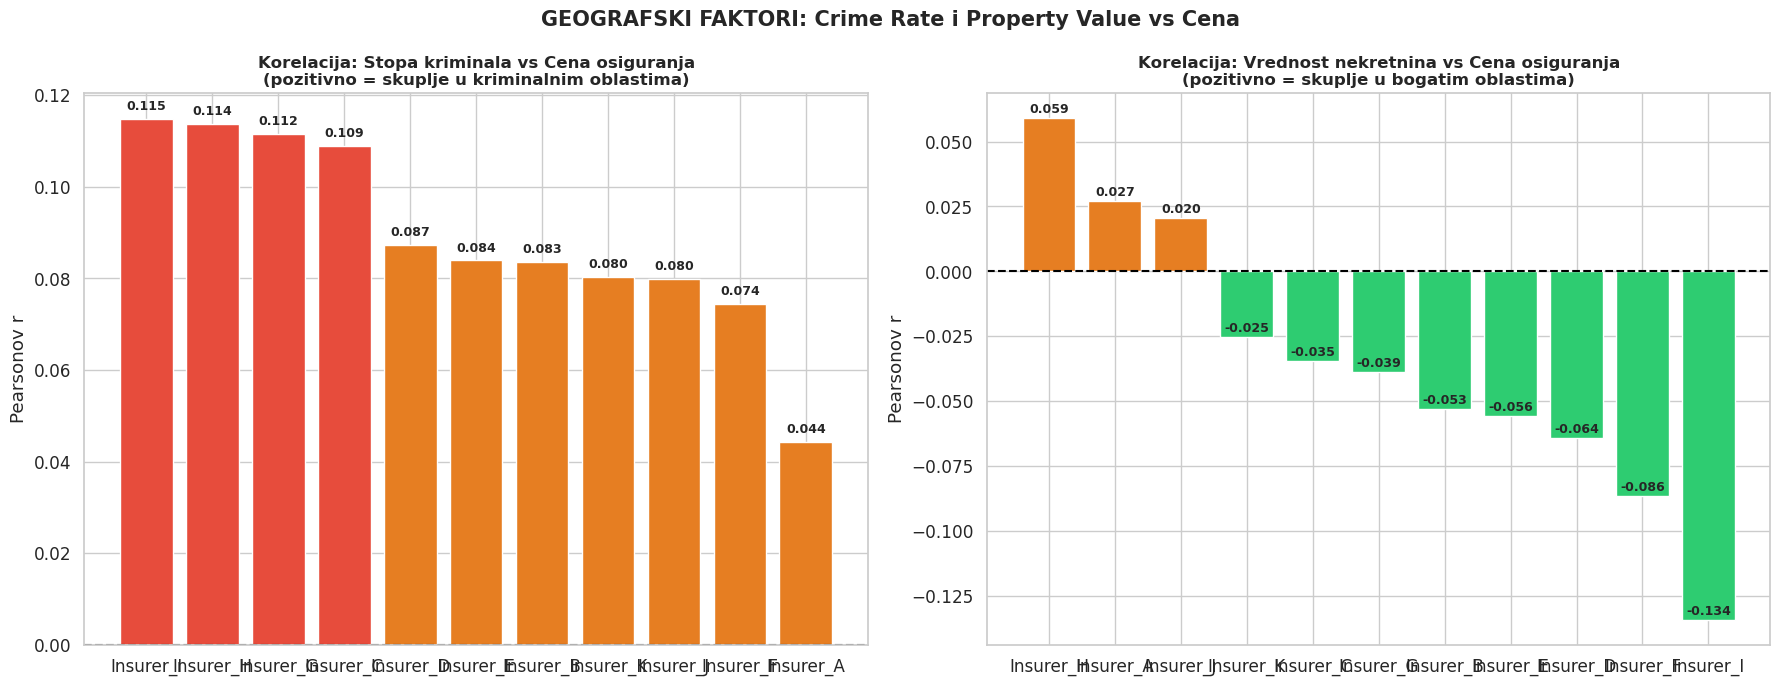

In [49]:

# ============================================================
# ANALIZA J — GEOGRAPHIC HOTSPOTS (Province level)
# ============================================================
print("=== ANALIZA J: GEOGRAPHIC HOTSPOTS ===")

# Province level analiza
prov_prices = df.groupby('province')[insurer_cols].mean()
prov_prices.columns = [c.replace('_price', '') for c in prov_prices.columns]
prov_prices['avg_market_price'] = prov_prices.mean(axis=1)
prov_prices['num_insurers_quoting'] = df.groupby('province')[insurer_cols].apply(
    lambda x: x.notnull().mean().mean() * 100)

top_expensive = prov_prices['avg_market_price'].sort_values(ascending=False).head(10)
top_cheap = prov_prices['avg_market_price'].sort_values().head(10)

# Postal code level — crime vs price
df['postal_code_average_property_value'] = pd.to_numeric(
    df['postal_code_average_property_value'], errors='coerce')

# Korelacija: crime rate vs prosečna cena
crime_corr = {}
prop_corr = {}
for ins in insurer_cols:
    ins_name = ins.replace('_price', '')
    valid = df[[ins, 'municipality_crimes_per_1000', 'postal_code_average_property_value']].dropna()
    crime_corr[ins_name] = valid[[ins, 'municipality_crimes_per_1000']].corr().iloc[0, 1]
    prop_corr[ins_name] = valid[[ins, 'postal_code_average_property_value']].corr().iloc[0, 1]

crime_corr_s = pd.Series(crime_corr).sort_values(ascending=False)
prop_corr_s  = pd.Series(prop_corr).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors_cr = ['#e74c3c' if v > 0.1 else '#2ecc71' if v < 0 else '#e67e22'
             for v in crime_corr_s.values]
axes[0].bar(crime_corr_s.index, crime_corr_s.values, color=colors_cr, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('Korelacija: Stopa kriminala vs Cena osiguranja\n(pozitivno = skuplje u kriminalnim oblastima)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Pearsonov r')
for i, v in enumerate(crime_corr_s.values):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

colors_pr = ['#e74c3c' if v > 0.1 else '#2ecc71' if v < 0 else '#e67e22'
             for v in prop_corr_s.values]
axes[1].bar(prop_corr_s.index, prop_corr_s.values, color=colors_pr, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Korelacija: Vrednost nekretnina vs Cena osiguranja\n(pozitivno = skuplje u bogatim oblastima)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Pearsonov r')
for i, v in enumerate(prop_corr_s.values):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('GEOGRAFSKI FAKTORI: Crime Rate i Property Value vs Cena', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/J_geographic_factors.png', dpi=150, bbox_inches='tight')


print("Top 10 najskupljih provincija (prosečna tržišna cena):")
for prov, val in top_expensive.items():
    print(f"  {prov}: {val:.0f}€")

print("\nTop 10 najjeftinijih provincija:")
for prov, val in top_cheap.items():
    print(f"  {prov}: {val:.0f}€")

print("\nKorelacija crime rate vs cena:")
for ins, val in crime_corr_s.items():
    print(f"  {ins}: r={val:.3f}")

print("\nKorelacija property value vs cena:")
for ins, val in prop_corr_s.items():
    print(f"  {ins}: r={val:.3f}")
print("✅ Analiza J gotova\n")

=== ANALIZA K: COMPETITIVE BLIND SPOTS ===
Tržišni prosek quote rate (coverage × CFR):
cfr_group      Veoma loš (<-1)  Loš (-1 do 0)  Novi (0-3)  Dobar (3-7)  Odličan (7-15)  Veteran (15+)
coverage                                                                                             
casco                     44.9           64.7        64.6         69.2            69.4           67.4
limited_casco             43.0           57.3        61.2         68.8            69.6           66.6
mtpl                      42.5           67.4        70.9         76.2            77.5            NaN
✅ Analiza K gotova

Tržišni prosek quote rate (coverage × CFR):
cfr_group      Veoma loš (<-1)  Loš (-1 do 0)  Novi (0-3)  Dobar (3-7)  Odličan (7-15)  Veteran (15+)
coverage                                                                                             
casco                     44.9           64.7        64.6         69.2            69.4           67.4
limited_casco             43.0   

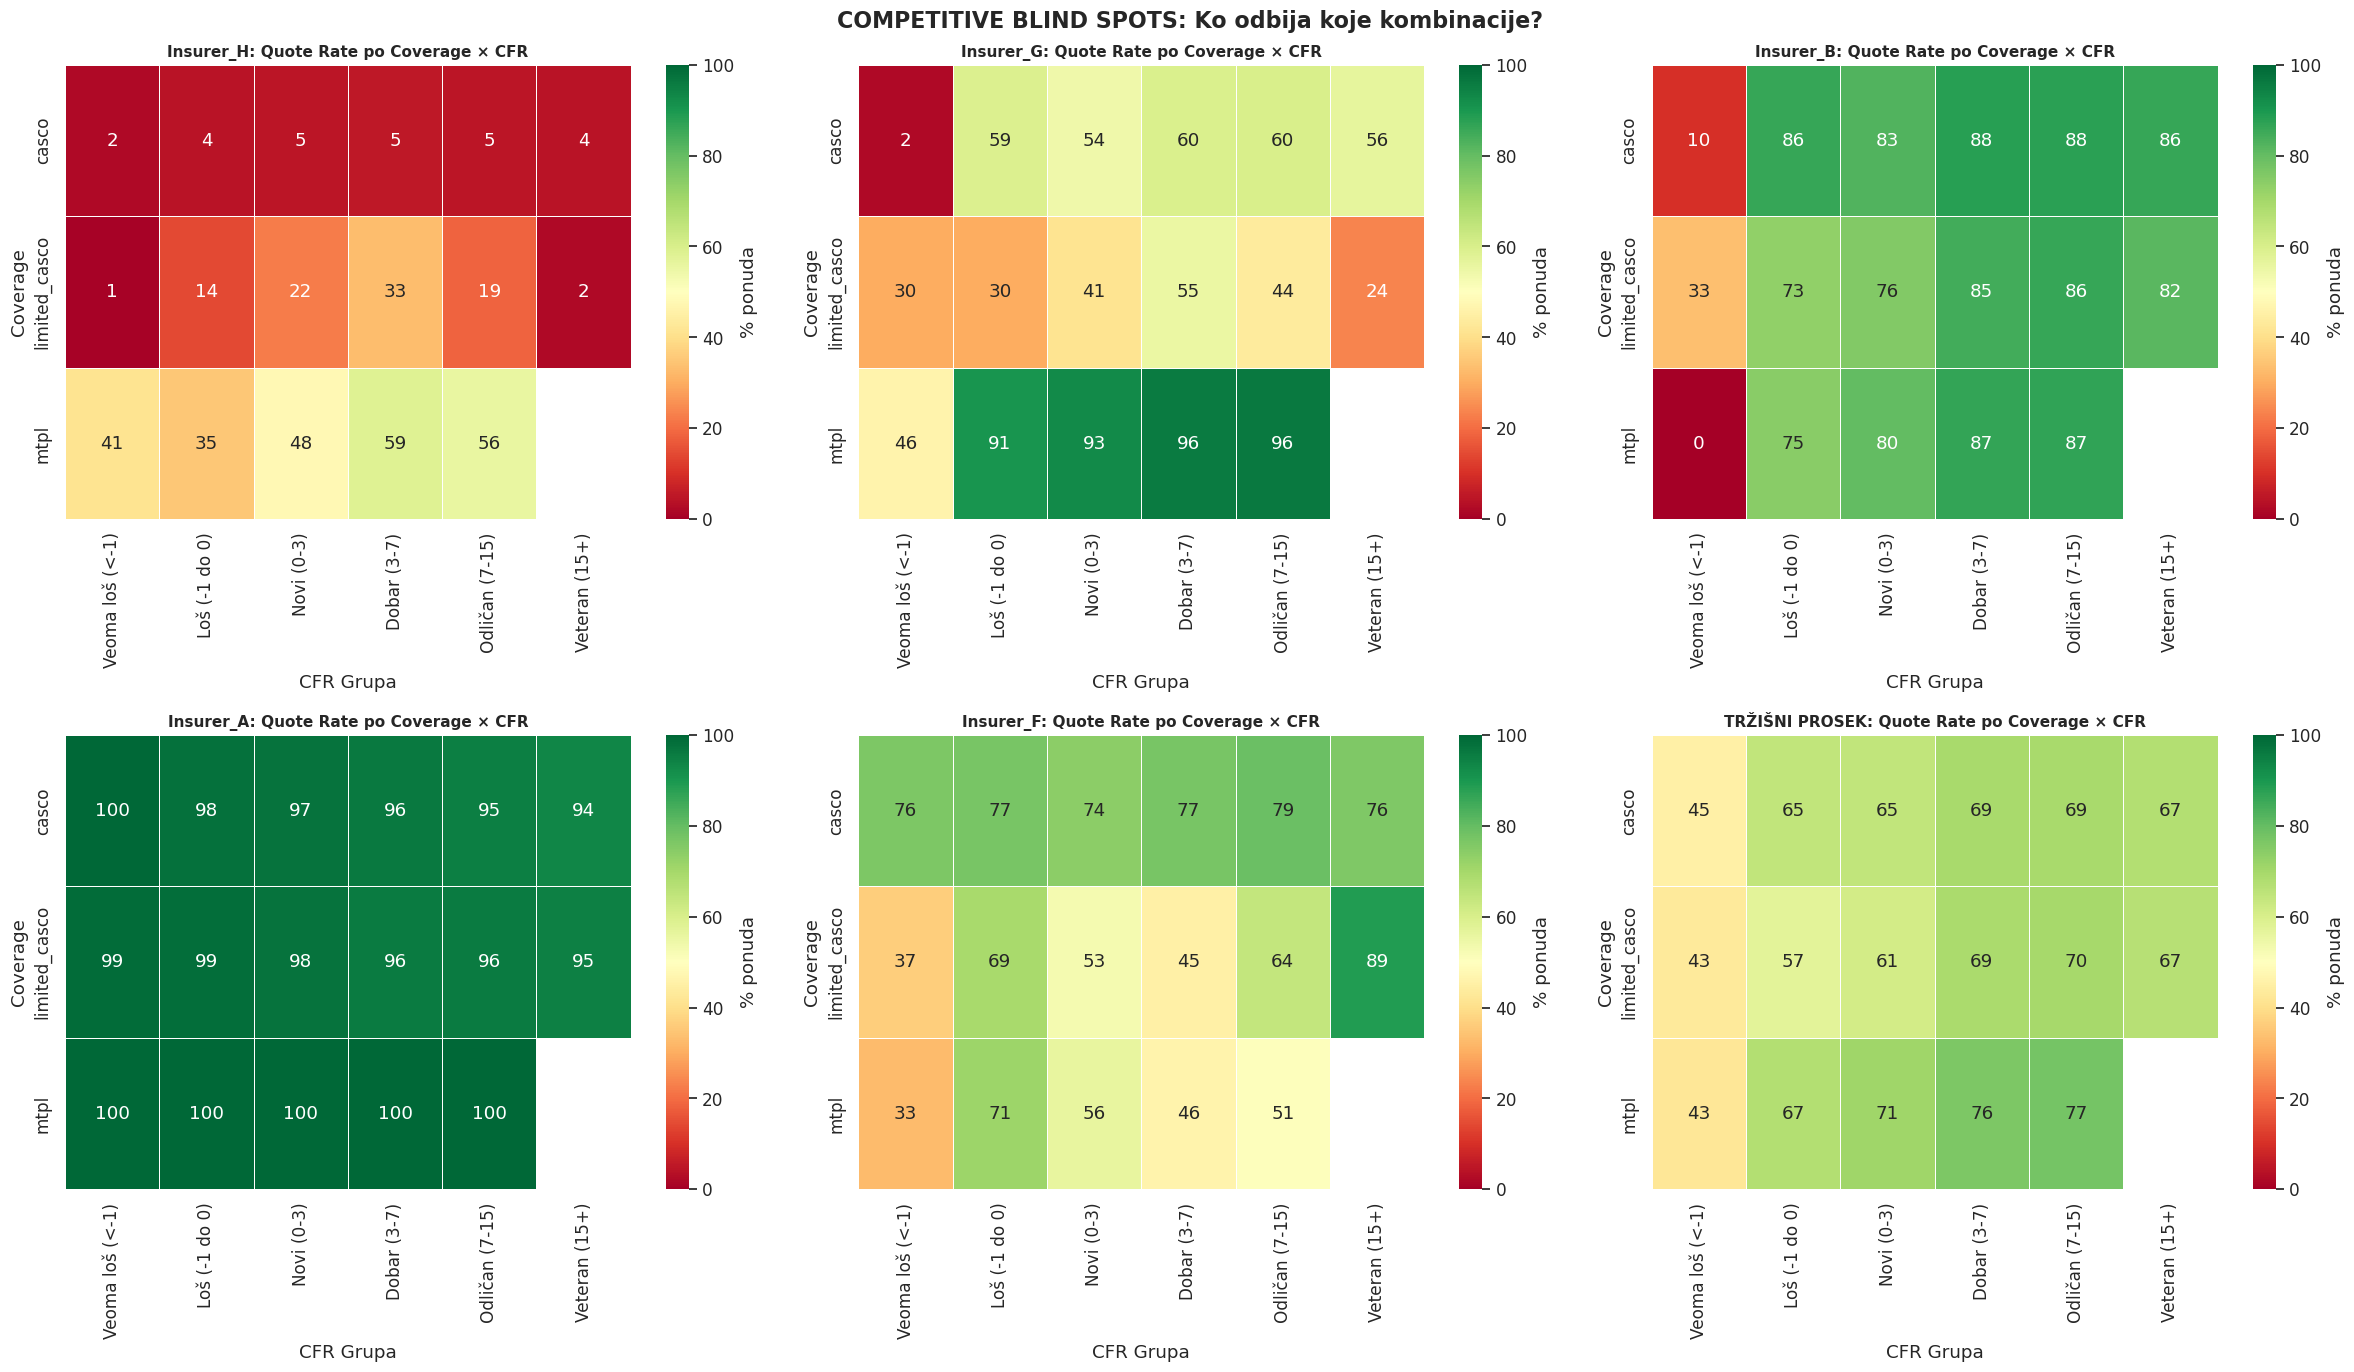

In [50]:

# ============================================================
# ANALIZA K — COMPETITIVE BLIND SPOTS MATRIX
# ============================================================
print("=== ANALIZA K: COMPETITIVE BLIND SPOTS ===")

# Za svaki insurer: koje kombinacije (coverage × cfr_group) odbijaju?
blind_spots = {}
for ins in insurer_cols:
    ins_name = ins.replace('_price', '')
    qr = df.groupby(['coverage', 'cfr_group'], observed=True)[ins].apply(
        lambda x: x.notnull().mean() * 100
    ).unstack(level=1)
    blind_spots[ins_name] = qr

# Prosečni quote rate po coverage × cfr_group (tržišni prosek)
market_avg = pd.DataFrame()
for ins in insurer_cols:
    qr = df.groupby(['coverage', 'cfr_group'], observed=True)[ins].apply(
        lambda x: x.notnull().mean() * 100
    )
    market_avg[ins.replace('_price', '')] = qr

market_avg_mean = market_avg.mean(axis=1).unstack(level=1)

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes_flat = axes.flatten()

# Prikaži za 5 najinteresantnijih insurera + market average
interesting = ['Insurer_H', 'Insurer_G', 'Insurer_B', 'Insurer_A', 'Insurer_F']
for i, ins_name in enumerate(interesting):
    sns.heatmap(blind_spots[ins_name], annot=True, fmt='.0f',
                cmap='RdYlGn', linewidths=0.5, ax=axes_flat[i],
                vmin=0, vmax=100,
                cbar_kws={'label': '% ponuda'})
    axes_flat[i].set_title(f'{ins_name}: Quote Rate po Coverage × CFR',
                           fontsize=11, fontweight='bold')
    axes_flat[i].set_xlabel('CFR Grupa')
    axes_flat[i].set_ylabel('Coverage')

# Poslednji: tržišni prosek
sns.heatmap(market_avg_mean, annot=True, fmt='.0f',
            cmap='RdYlGn', linewidths=0.5, ax=axes_flat[5],
            vmin=0, vmax=100,
            cbar_kws={'label': '% ponuda'})
axes_flat[5].set_title('TRŽIŠNI PROSEK: Quote Rate po Coverage × CFR',
                       fontsize=11, fontweight='bold')
axes_flat[5].set_xlabel('CFR Grupa')
axes_flat[5].set_ylabel('Coverage')

plt.suptitle('COMPETITIVE BLIND SPOTS: Ko odbija koje kombinacije?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/K_blind_spots.png', dpi=150, bbox_inches='tight')


print("Tržišni prosek quote rate (coverage × CFR):")
print(market_avg_mean.round(1).to_string())
print("✅ Analiza K gotova\n")

=== ANALIZA L: VEHICLE AGE × COVERAGE INTERACTION ===
CASCO Quote Rate po starosti vozila (%):
                   Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
vehicle_age_group                                                                                                                         
0-3g                    95.3       86.3       88.1       83.1       69.2       74.2       18.7        1.3       49.4       68.6       58.9
3-7g                    96.2       85.7       84.6       81.2       60.5       77.8       70.9        6.3       50.3       76.6       62.0
7-12g                   93.8       87.3       86.1       85.8       62.3       78.1       71.4        2.0       68.5       72.0       67.4
12-20g                  97.2       89.1       88.5       82.0       73.1       80.1       81.4        0.6       71.8       33.4       70.7
20g+                   100.0        0.0        0.0       33.3        0.

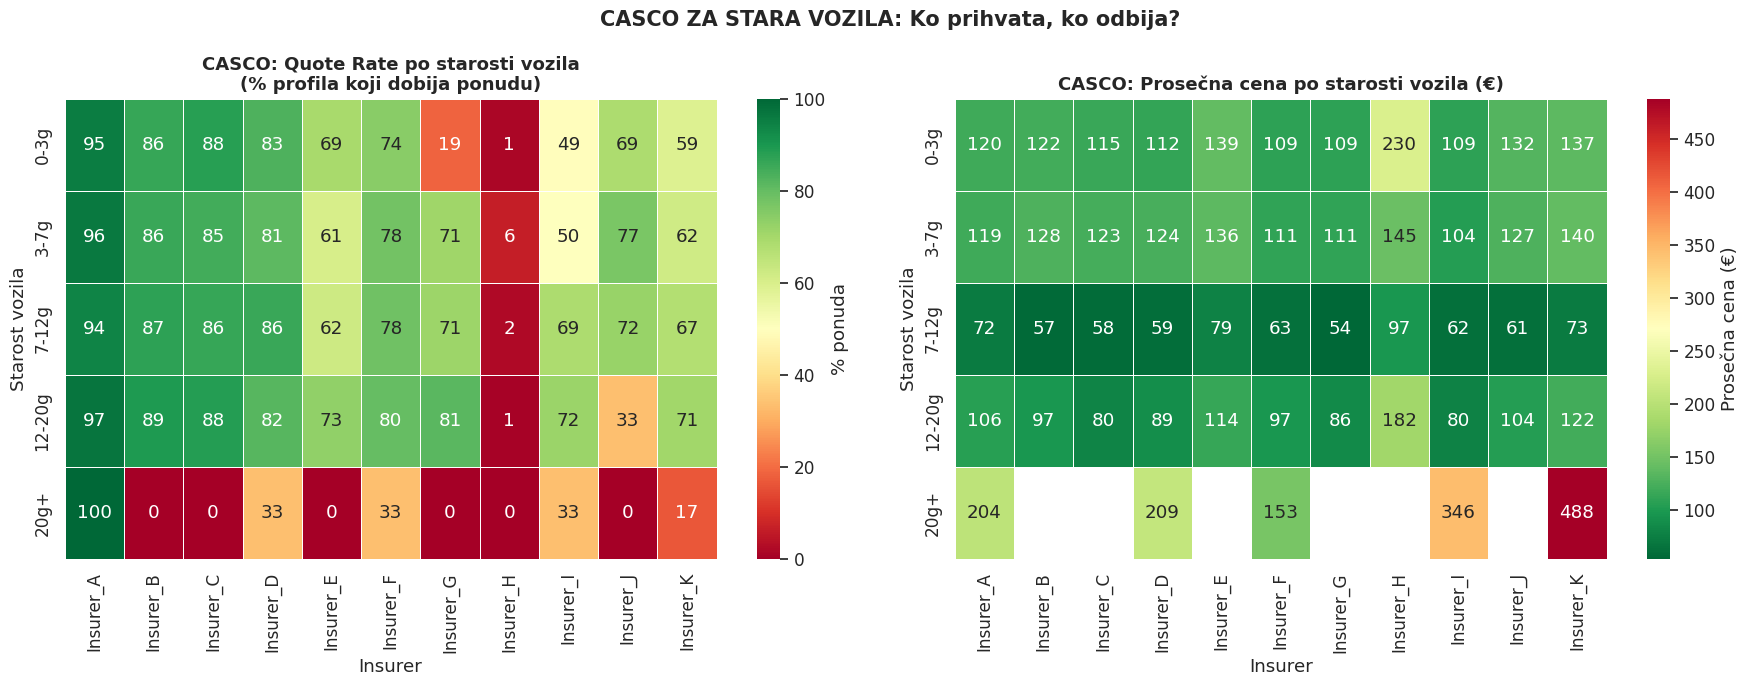

In [51]:

# ============================================================
# ANALIZA L — VEHICLE AGE × COVERAGE INTERACTION
# ============================================================
print("=== ANALIZA L: VEHICLE AGE × COVERAGE INTERACTION ===")

# Ko quotuje stara vozila za casco?
casco_df = df[df['coverage'] == 'casco'].copy()
casco_df['vehicle_age_group'] = pd.cut(
    casco_df['vehicle_age_calc'],
    bins=[0, 3, 7, 12, 20, 100],
    labels=['0-3g', '3-7g', '7-12g', '12-20g', '20g+']
)

casco_qr = pd.DataFrame()
casco_price = pd.DataFrame()
for ins in insurer_cols:
    ins_name = ins.replace('_price', '')
    casco_qr[ins_name] = casco_df.groupby('vehicle_age_group', observed=True)[ins].apply(
        lambda x: x.notnull().mean() * 100)
    casco_price[ins_name] = casco_df.groupby('vehicle_age_group', observed=True)[ins].mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(casco_qr, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': '% ponuda'})
axes[0].set_title('CASCO: Quote Rate po starosti vozila\n(% profila koji dobija ponudu)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Insurer')
axes[0].set_ylabel('Starost vozila')

sns.heatmap(casco_price, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Prosečna cena (€)'})
axes[1].set_title('CASCO: Prosečna cena po starosti vozila (€)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Insurer')
axes[1].set_ylabel('Starost vozila')

plt.suptitle('CASCO ZA STARA VOZILA: Ko prihvata, ko odbija?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/L_vehicle_age_casco.png', dpi=150, bbox_inches='tight')


print("CASCO Quote Rate po starosti vozila (%):")
print(casco_qr.round(1).to_string())
print("\nCASCO Prosečna cena po starosti vozila (€):")
print(casco_price.round(0).to_string())
print("✅ Analiza L gotova\n")

=== ANALIZA M: FUEL TYPE EFFECT ===
Fuel type distribucija:
vehicle_fuel_type
petrol                    394097
petrol_electric_hybrid     80616
electric                   35453
diesel                     25558
petrol_gas                  3928
other                       1484
gas                          156
Name: count, dtype: int64

Prosečna cena po fuel type (top 5):
                   Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
vehicle_fuel_type                                                                                                                         
electric               136.0      129.0      130.0      113.0      159.0      111.0      110.0      188.0      102.0      140.0      125.0
petrol                  87.0       91.0       79.0       92.0      108.0       90.0       77.0      109.0       91.0       94.0      118.0
diesel                 110.0      115.0      106.0      111.0      146.0

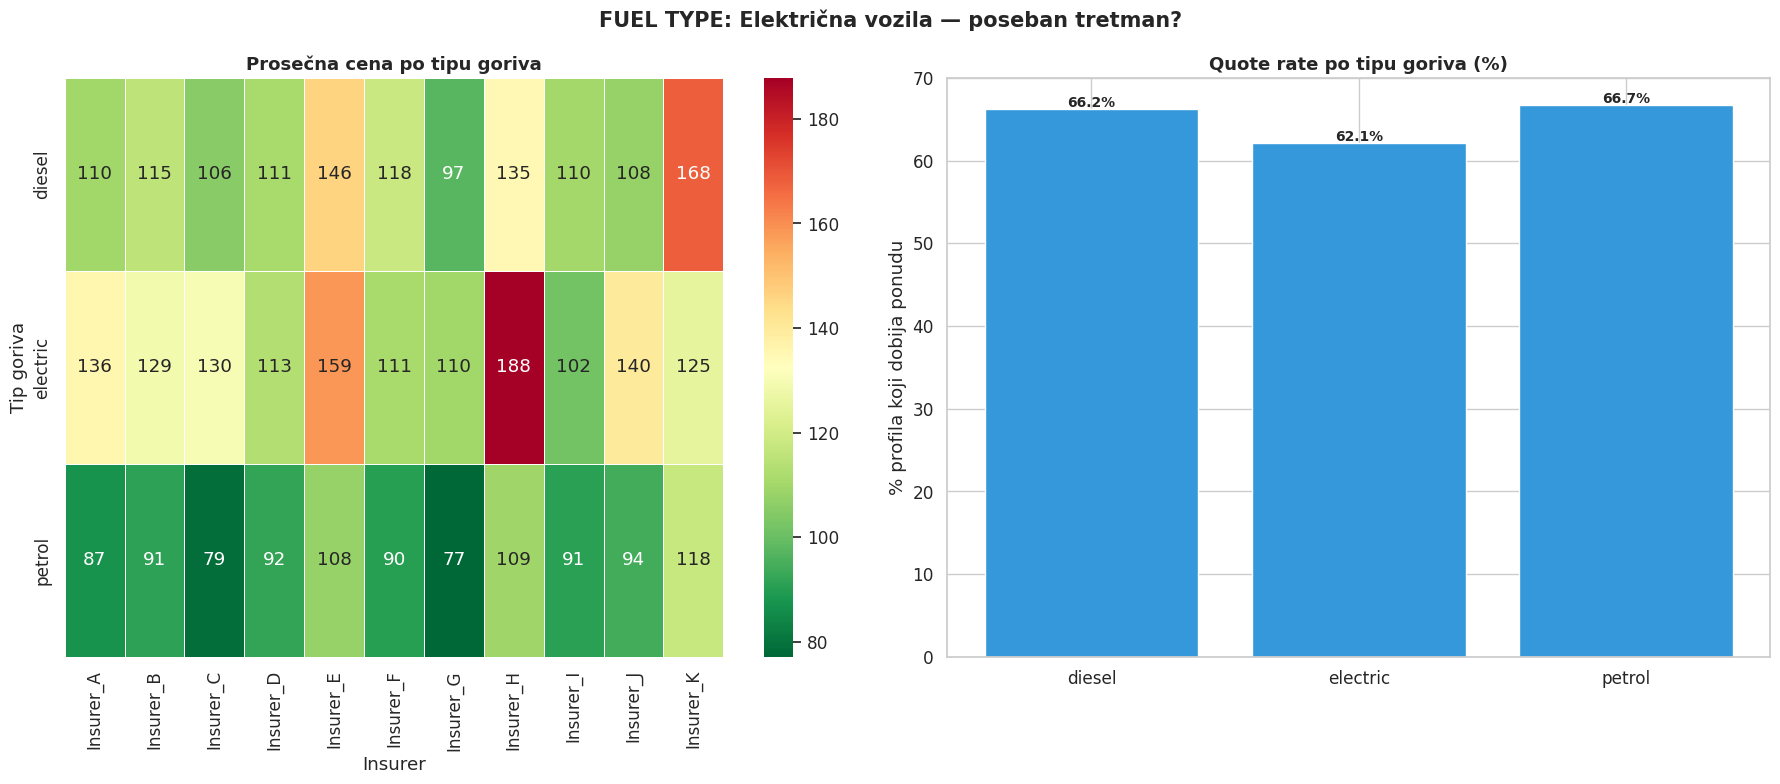

In [52]:

# ============================================================
# ANALIZA M — FUEL TYPE EFFECT
# ============================================================
print("=== ANALIZA M: FUEL TYPE EFFECT ===")

print("Fuel type distribucija:")
print(df['vehicle_fuel_type'].value_counts())

fuel_prices = df.groupby('vehicle_fuel_type')[insurer_cols].mean()
fuel_prices.columns = [c.replace('_price', '') for c in fuel_prices.columns]
fuel_quote = df.groupby('vehicle_fuel_type')[insurer_cols].apply(
    lambda x: x.notnull().mean() * 100).mean(axis=1)

# Fokus na električna vs benzin vs dizel
key_fuels = ['electric', 'petrol', 'diesel'] if 'electric' in df['vehicle_fuel_type'].values else \
            [f for f in df['vehicle_fuel_type'].value_counts().head(5).index]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

fuel_sub = fuel_prices.loc[fuel_prices.index.isin(key_fuels)]
sns.heatmap(fuel_sub, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Prosečna cena po tipu goriva', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Insurer')
axes[0].set_ylabel('Tip goriva')

fuel_quote_sub = fuel_quote[fuel_quote.index.isin(key_fuels)]
axes[1].bar(fuel_quote_sub.index.astype(str), fuel_quote_sub.values, color='#3498db', edgecolor='white')
axes[1].set_title('Quote rate po tipu goriva (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% profila koji dobija ponudu')
for i, v in enumerate(fuel_quote_sub.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('FUEL TYPE: Električna vozila — poseban tretman?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/M_fuel_type.png', dpi=150, bbox_inches='tight')


print("\nProsečna cena po fuel type (top 5):")
print(fuel_prices.loc[key_fuels].round(0).to_string())
print("\nQuote rate po fuel type:")
print(fuel_quote.loc[key_fuels].round(1))
print("✅ Analiza M gotova\n")

=== ANALIZA N: PRICE DISPERSION ===
Prosečni koeficijent varijacije cena: 0.263
Prosečni price range (max-min): 78€
Prosečni max/min ratio: 2.08x
Prosečni koeficijent varijacije cena: 0.263
Prosečni price range (max-min): 78€
Prosečni max/min ratio: 2.08x

CV po coverage tipu:
coverage
mtpl             0.298
limited_casco    0.261
casco            0.237
Name: price_cv, dtype: float64

CV po vehicle value grupi:
vehicle_value_group
10-20k    0.279
<10k      0.275
20-35k    0.269
75k+      0.262
35-50k    0.245
50-75k    0.242
Name: price_cv, dtype: float64
✅ Analiza N gotova


CV po coverage tipu:
coverage
mtpl             0.298
limited_casco    0.261
casco            0.237
Name: price_cv, dtype: float64

CV po vehicle value grupi:
vehicle_value_group
10-20k    0.279
<10k      0.275
20-35k    0.269
75k+      0.262
35-50k    0.245
50-75k    0.242
Name: price_cv, dtype: float64
✅ Analiza N gotova



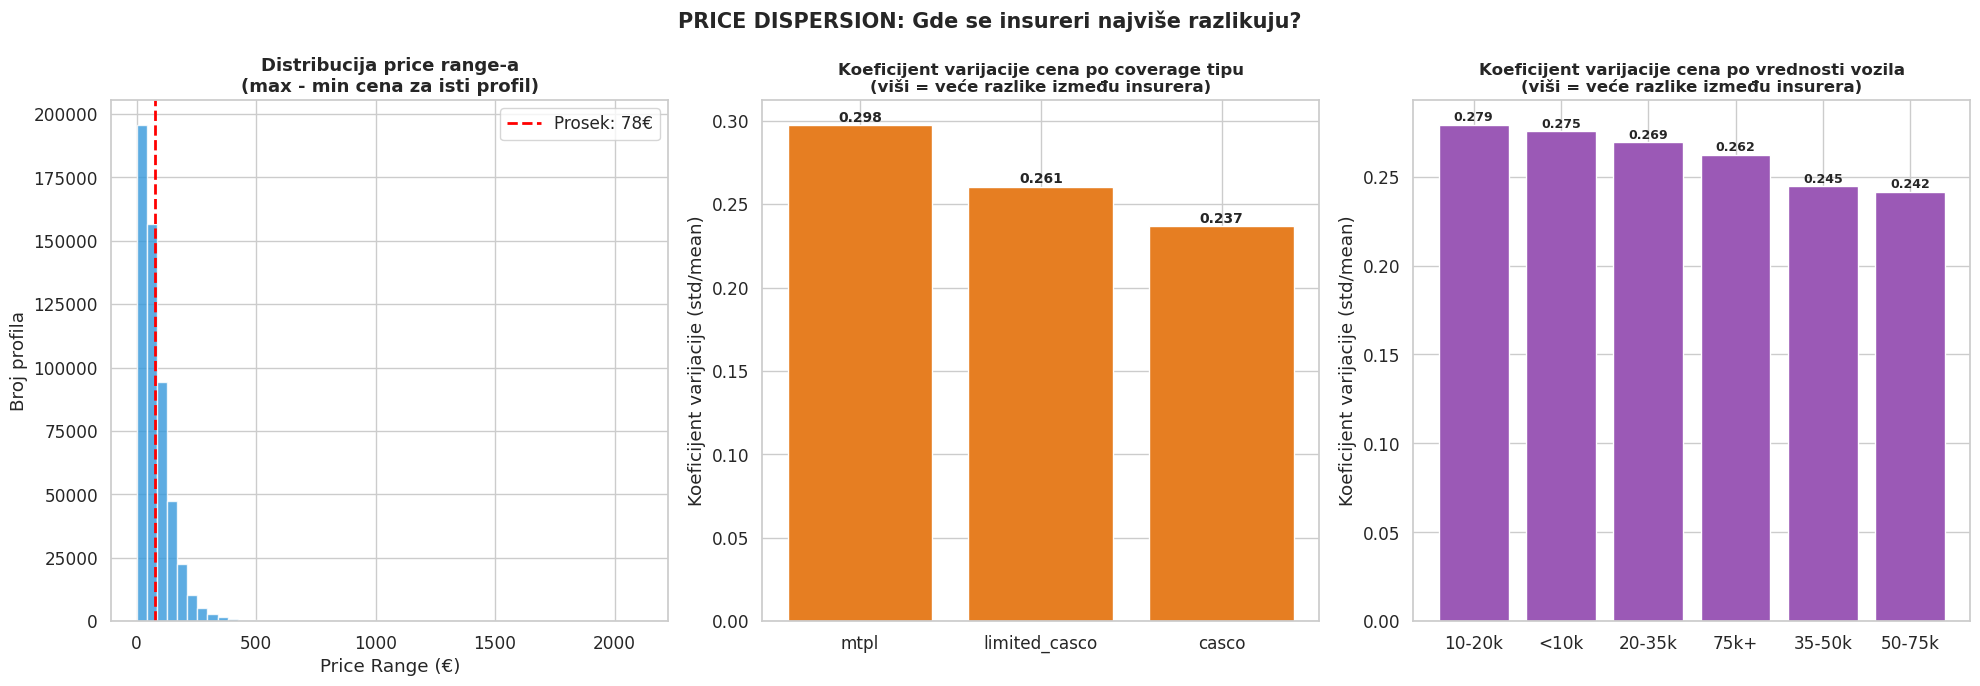

In [53]:

# ============================================================
# ANALIZA N — PRICE DISPERSION (Koliko se insureri razlikuju za isti profil?)
# ============================================================
print("=== ANALIZA N: PRICE DISPERSION ===")

# Za svaki profil: std / mean cena = koeficijent varijacije
df['price_cv'] = df[insurer_cols].std(axis=1) / df[insurer_cols].mean(axis=1)
df['price_range'] = df[insurer_cols].max(axis=1) - df[insurer_cols].min(axis=1)
df['price_max_min_ratio'] = df[insurer_cols].max(axis=1) / df[insurer_cols].min(axis=1)

print(f"Prosečni koeficijent varijacije cena: {df['price_cv'].mean():.3f}")
print(f"Prosečni price range (max-min): {df['price_range'].mean():.0f}€")
print(f"Prosečni max/min ratio: {df['price_max_min_ratio'].mean():.2f}x")

# Koji segmenti imaju najveću disperziju?
disp_by_coverage = df.groupby('coverage')['price_cv'].mean().sort_values(ascending=False)
disp_by_value = df.groupby('vehicle_value_group', observed=True)['price_cv'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Distribucija price range
axes[0].hist(df['price_range'].dropna(), bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df['price_range'].mean(), color='red', linewidth=2, linestyle='--',
                label=f'Prosek: {df["price_range"].mean():.0f}€')
axes[0].set_title('Distribucija price range-a\n(max - min cena za isti profil)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price Range (€)')
axes[0].set_ylabel('Broj profila')
axes[0].legend()

# CV po coverage
axes[1].bar(disp_by_coverage.index, disp_by_coverage.values, color='#e67e22', edgecolor='white')
axes[1].set_title('Koeficijent varijacije cena po coverage tipu\n(viši = veće razlike između insurera)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Koeficijent varijacije (std/mean)')
for i, v in enumerate(disp_by_coverage.values):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# CV po vehicle value
axes[2].bar(disp_by_value.index.astype(str), disp_by_value.values, color='#9b59b6', edgecolor='white')
axes[2].set_title('Koeficijent varijacije cena po vrednosti vozila\n(viši = veće razlike između insurera)',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Koeficijent varijacije (std/mean)')
for i, v in enumerate(disp_by_value.values):
    axes[2].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('PRICE DISPERSION: Gde se insureri najviše razlikuju?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/N_price_dispersion.png', dpi=150, bbox_inches='tight')


print("\nCV po coverage tipu:")
print(disp_by_coverage.round(3))
print("\nCV po vehicle value grupi:")
print(disp_by_value.round(3))
print("✅ Analiza N gotova\n")

=== ANALIZA O: IMPORTED VEHICLES ===
Uvezena vozila: 157,696 (29.1%)
Uvezena u poslednjih 12 meseci: 31,956.0 (5.9%)

Efekat uvoza na cenu (%):
  Insurer_C: +17.0%
  Insurer_A: +14.0%
  Insurer_J: +13.2%
  Insurer_B: +10.0%
  Insurer_D: +8.6%
  Insurer_F: +8.0%
  Insurer_H: +6.4%
  Insurer_G: +6.2%
  Insurer_E: +6.1%
  Insurer_K: +5.4%
  Insurer_I: +2.2%

Efekat uvoza na quote rate (pp):
  Insurer_E: -11.5pp
  Insurer_K: -9.9pp
  Insurer_G: -7.2pp
  Insurer_B: -6.9pp
  Insurer_D: -6.4pp
  Insurer_F: -5.0pp
  Insurer_I: -4.8pp
  Insurer_J: -4.0pp
  Insurer_C: -3.5pp
  Insurer_H: -3.1pp
  Insurer_A: +0.3pp
✅ Analiza O gotova


Efekat uvoza na cenu (%):
  Insurer_C: +17.0%
  Insurer_A: +14.0%
  Insurer_J: +13.2%
  Insurer_B: +10.0%
  Insurer_D: +8.6%
  Insurer_F: +8.0%
  Insurer_H: +6.4%
  Insurer_G: +6.2%
  Insurer_E: +6.1%
  Insurer_K: +5.4%
  Insurer_I: +2.2%

Efekat uvoza na quote rate (pp):
  Insurer_E: -11.5pp
  Insurer_K: -9.9pp
  Insurer_G: -7.2pp
  Insurer_B: -6.9pp
  Insurer_D: 

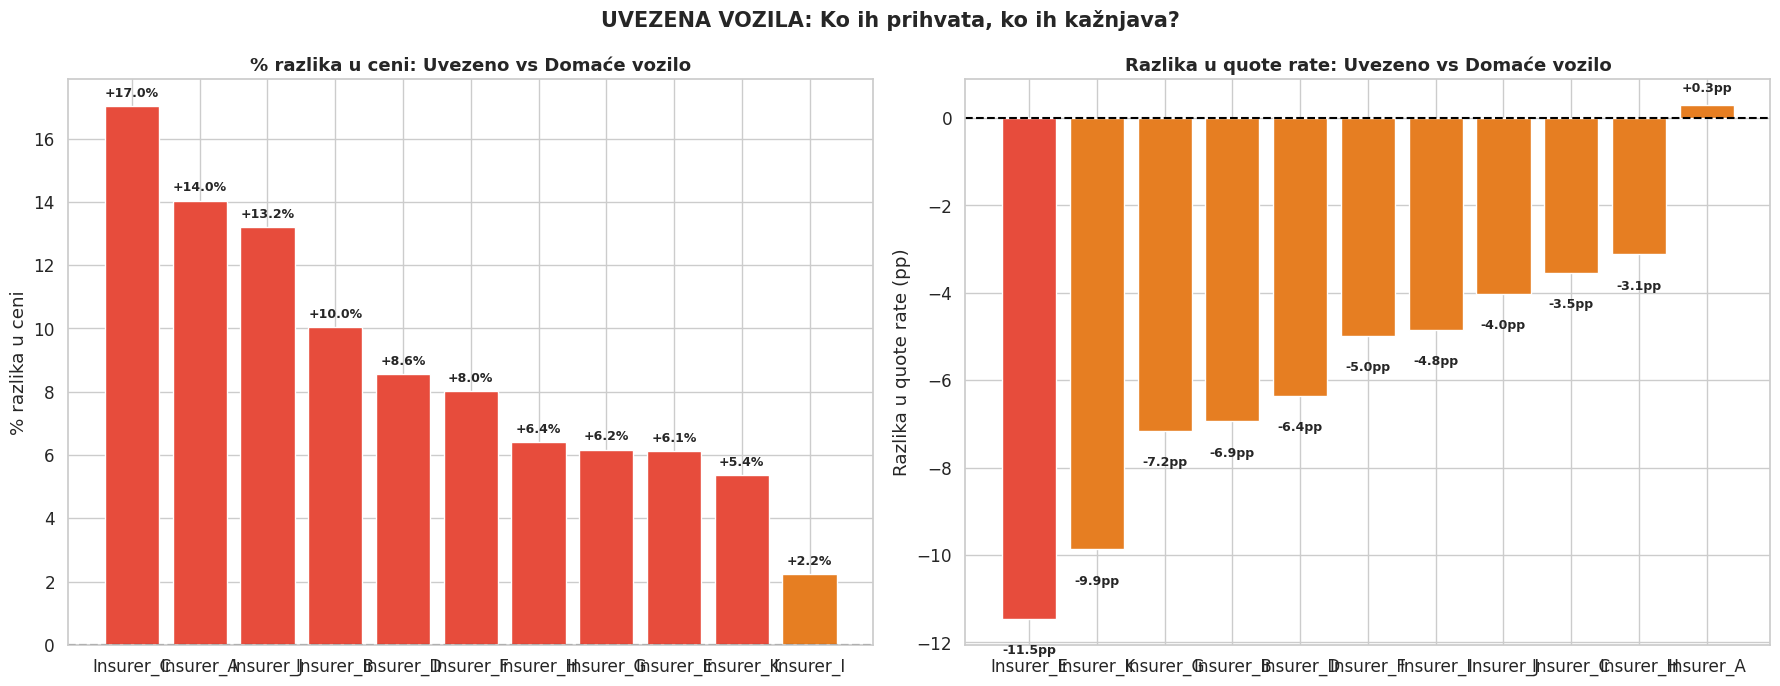

In [54]:

# ============================================================
# ANALIZA O — IMPORTED VEHICLES
# ============================================================
print("=== ANALIZA O: IMPORTED VEHICLES ===")

df['is_imported_bin'] = df['vehicle_is_imported'].map({'yes': 1, 'no': 0, True: 1, False: 0, 1: 1, 0: 0}).fillna(0)
df['is_imported_recent'] = df['vehicle_is_imported_within_last_12_months'].map(
    {'yes': 1, 'no': 0, True: 1, False: 0, 1: 1, 0: 0}).fillna(0)

print(f"Uvezena vozila: {df['is_imported_bin'].sum():,} ({df['is_imported_bin'].mean()*100:.1f}%)")
print(f"Uvezena u poslednjih 12 meseci: {df['is_imported_recent'].sum():,} ({df['is_imported_recent'].mean()*100:.1f}%)")

imported = df[df['is_imported_bin'] == 1]
domestic = df[df['is_imported_bin'] == 0]

imp_price_diff = {}
imp_quote_diff = {}
for ins in insurer_cols:
    ins_name = ins.replace('_price', '')
    p_imp = imported[ins].mean()
    p_dom = domestic[ins].mean()
    q_imp = imported[ins].notnull().mean() * 100
    q_dom = domestic[ins].notnull().mean() * 100
    imp_price_diff[ins_name] = (p_imp - p_dom) / p_dom * 100 if p_dom > 0 else 0
    imp_quote_diff[ins_name] = q_imp - q_dom

imp_price_s = pd.Series(imp_price_diff).sort_values(ascending=False)
imp_quote_s = pd.Series(imp_quote_diff).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors_imp = ['#e74c3c' if v > 5 else '#2ecc71' if v < -5 else '#e67e22'
              for v in imp_price_s.values]
axes[0].bar(imp_price_s.index, imp_price_s.values, color=colors_imp, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('% razlika u ceni: Uvezeno vs Domaće vozilo',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('% razlika u ceni')
for i, v in enumerate(imp_price_s.values):
    axes[0].text(i, v + (0.3 if v >= 0 else -1.2), f'{v:+.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

colors_qimp = ['#e74c3c' if v < -10 else '#2ecc71' if v > 5 else '#e67e22'
               for v in imp_quote_s.values]
axes[1].bar(imp_quote_s.index, imp_quote_s.values, color=colors_qimp, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Razlika u quote rate: Uvezeno vs Domaće vozilo',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Razlika u quote rate (pp)')
for i, v in enumerate(imp_quote_s.values):
    axes[1].text(i, v + (0.3 if v >= 0 else -0.8), f'{v:+.1f}pp',
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('UVEZENA VOZILA: Ko ih prihvata, ko ih kažnjava?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/O_imported_vehicles.png', dpi=150, bbox_inches='tight')


print("\nEfekat uvoza na cenu (%):")
for ins, val in imp_price_s.items():
    print(f"  {ins}: {val:+.1f}%")
print("\nEfekat uvoza na quote rate (pp):")
for ins, val in imp_quote_s.items():
    print(f"  {ins}: {val:+.1f}pp")
print("✅ Analiza O gotova\n")

=== ANALIZA P: PLANNED ANNUAL MILEAGE ===
Mileage distribucija:
mileage_group
<10k km      228612
10-20k km    251547
20-30k km     45813
30-50k km     15320
50k+ km           0
Name: count, dtype: int64
Mileage distribucija:
mileage_group
<10k km      228612
10-20k km    251547
20-30k km     45813
30-50k km     15320
50k+ km           0
Name: count, dtype: int64
\nProsečna cena po kilometraži:
               Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
mileage_group                                                                                                                         
<10k km             93.0      100.0       87.0       96.0      115.0       97.0       84.0      114.0       99.0       98.0      124.0
10-20k km           97.0       98.0       90.0       98.0      113.0       96.0       85.0      116.0       91.0      107.0      122.0
20-30k km          106.0       99.0       93.0      104.0     

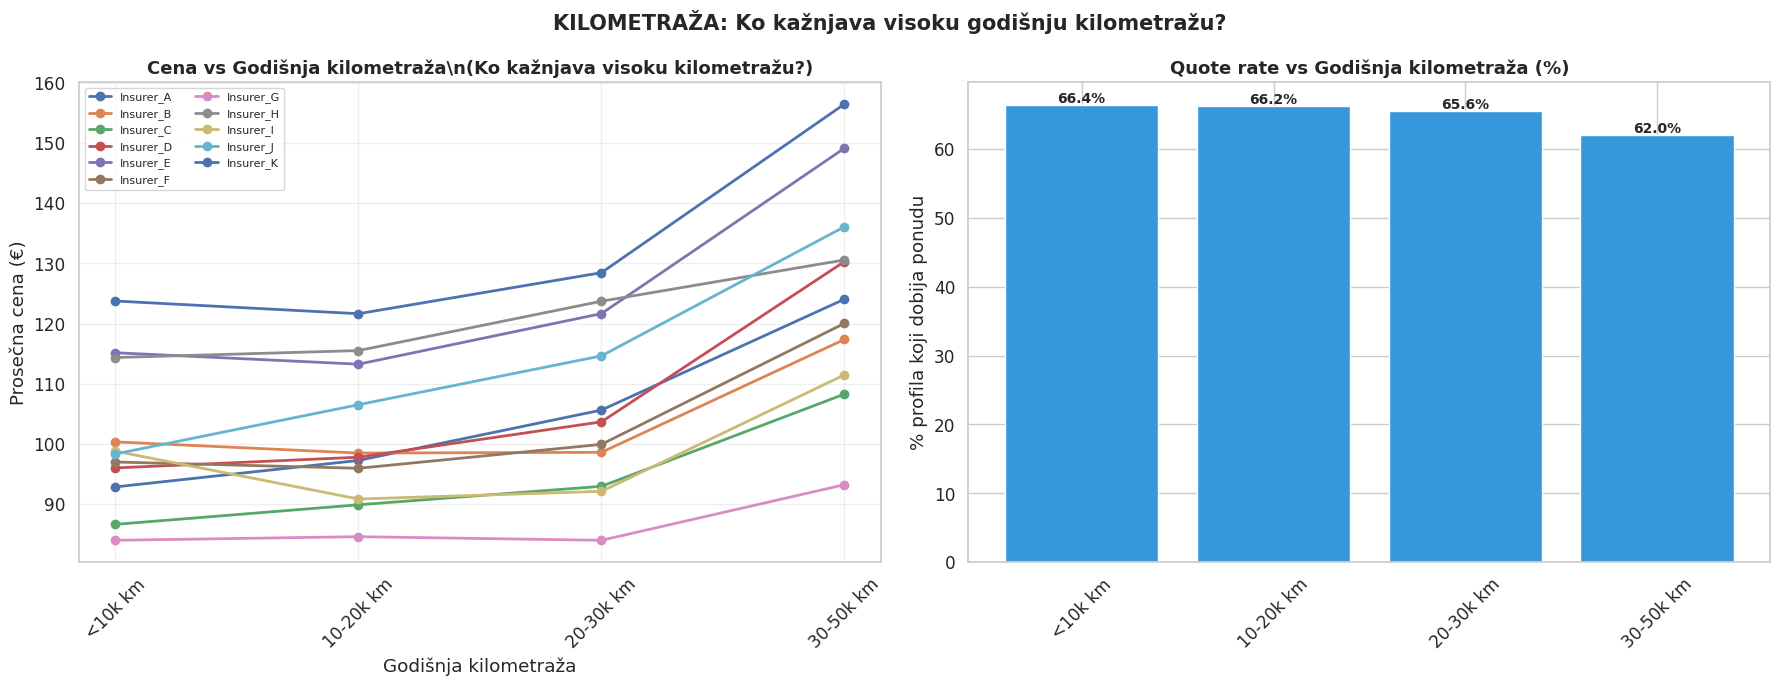

In [55]:

# ============================================================
# ANALIZA P — MILEAGE EFFECT
# ============================================================
print("=== ANALIZA P: PLANNED ANNUAL MILEAGE ===")

df['vehicle_planned_annual_mileage'] = pd.to_numeric(df['vehicle_planned_annual_mileage'], errors='coerce')
df['mileage_group'] = pd.cut(
    df['vehicle_planned_annual_mileage'],
    bins=[0, 10000, 20000, 30000, 50000, 999999],
    labels=['<10k km', '10-20k km', '20-30k km', '30-50k km', '50k+ km']
)

print("Mileage distribucija:")
print(df['mileage_group'].value_counts().sort_index())

mileage_prices = df.groupby('mileage_group', observed=True)[insurer_cols].mean()
mileage_prices.columns = [c.replace('_price', '') for c in mileage_prices.columns]
mileage_quote = df.groupby('mileage_group', observed=True)[insurer_cols].apply(
    lambda x: x.notnull().mean() * 100).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ins in mileage_prices.columns:
    axes[0].plot(mileage_prices.index.astype(str), mileage_prices[ins],
                 marker='o', linewidth=2, label=ins)
axes[0].set_title('Cena vs Godišnja kilometraža\\n(Ko kažnjava visoku kilometražu?)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Godišnja kilometraža')
axes[0].set_ylabel('Prosečna cena (€)')
axes[0].legend(loc='upper left', fontsize=8, ncol=2)
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(mileage_quote.index.astype(str), mileage_quote.values, color='#3498db', edgecolor='white')
axes[1].set_title('Quote rate vs Godišnja kilometraža (%)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('% profila koji dobija ponudu')
for i, v in enumerate(mileage_quote.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('KILOMETRAŽA: Ko kažnjava visoku godišnju kilometražu?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/P_mileage.png', dpi=150, bbox_inches='tight')

print("\\nProsečna cena po kilometraži:")
print(mileage_prices.round(0).to_string())
print("✅ Analiza P gotova\\n")